# Agricultural Price Forecasting: Benchmark Study on Bangladeshi Commodity Retail Prices

**Dataset:** Daily retail prices (BDT/kg) for 5 Bangladeshi commodities — novel public benchmark  
**Period:** July 2020 – June 2025 (1,779 observations per commodity)  
**Models:** Naïve Persistence · SARIMA · Prophet · BiLSTM · Transformer · T2V-Transformer · Informer (7 total)  
**Contribution:** Dataset release + heterogeneous forecastability analysis + learnable temporal encoding ablation

---

### Directory structure expected under the project root
```
Dataset/
  garlic/garlic.csv
  chickpea/chickpea.csv
  green_chilli/green_chilli.csv
  cucumber/cucumber.csv
  sweet_pumpkin/sweet_pumpkin.csv
```
Each CSV must have columns: `date`, `price`

### Cell execution order
Run cells top-to-bottom. Long cells: Cell 7 (Informer, ~5 min), Cell 8 (main loop, ~25-30 min).


In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────
# Run once per Colab session
!pip install -q pmdarima prophet statsmodels scikit-learn seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
sys.path.insert(0, '/content/drive/MyDrive/Research/Informer Time Series/Experiments/bangladesh-agri-price-forecast')
os.chdir('/content/drive/MyDrive/Research/Informer Time Series/Experiments/bangladesh-agri-price-forecast')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from agri_forecast.models import BiLSTM, VanillaTransformer, T2V_Transformer, NaivePersistence
from agri_forecast.utils import (
    prepare_commodity, compute_metrics,
    train_model, evaluate_model, evaluate_naive,
    run_sarima, run_prophet,
    plot_forecasts, plot_training_curves, plot_ablation,
    plot_decomposition, print_results_table, build_results_table,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
PyTorch version: 2.10.0+cu128


In [3]:
# ── Cell 3: Configuration ──────────────────────────────────────────────────

# ── Data paths ──
COMMODITY_PATHS = {
    'garlic':        'Dataset/garlic/garlic.csv',
    'chickpea':      'Dataset/chickpea/chickpea.csv',
    'green_chilli':  'Dataset/green_chilli/green_chilli.csv',
    'cucumber':      'Dataset/cucumber/cucumber.csv',
    'sweet_pumpkin': 'Dataset/sweet_pumpkin/sweet_pumpkin.csv',
}

# ── Window config ──
SEQ_LEN  = 90    # 3 months lookback
PRED_LEN = 14    # 2 weeks forecast horizon

# ── Model hyperparameters ──
# Kept small for Colab free tier — total params < 200K per model
MODEL_CFG = dict(
    input_dim  = 1,
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    d_ff       = 256,
    pred_len   = PRED_LEN,
    seq_len    = SEQ_LEN,
    t2v_dim    = 32,
    dropout    = 0.1,
    hidden_dim = 64,   # for BiLSTM
)

# ── Training config ──
TRAIN_CFG = dict(
    n_epochs   = 150,
    lr         = 1e-3,
    patience   = 20,
    batch_size = 32,
)

# Overfitting observed at dropout=0.1 for volatile commodities
DROPOUT_OVERRIDE = {
    'green_chilli':  0.3,
    'sweet_pumpkin': 0.3,
}

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print('Configuration set.')
print(f'  Lookback window : {SEQ_LEN} days')
print(f'  Forecast horizon: {PRED_LEN} days')
print(f'  Commodities     : {list(COMMODITY_PATHS.keys())}')

Configuration set.
  Lookback window : 90 days
  Forecast horizon: 14 days
  Commodities     : ['garlic', 'chickpea', 'green_chilli', 'cucumber', 'sweet_pumpkin']


In [4]:
# ── Cell 4: Data Analysis, ADF stationarity & R/S ratio ───────────────────
# R/S = residual_std / seasonal_std from STL decomposition
# Low R/S (<1) → strong seasonal structure → learnable temporal encoding likely helps
# High R/S (>2) → exogenous-shock dominated → naïve persistence hard to beat

from agri_forecast.utils.data import load_commodity_csv, temporal_split
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

print('='*60)
print('DATA SUMMARY + STATIONARITY + R/S RATIO')
print('='*60)

all_dfs   = {}
rs_ratios = {}

for commodity, path in COMMODITY_PATHS.items():
    df = load_commodity_csv(path)
    all_dfs[commodity] = df

    # ADF stationarity test
    adf_result    = adfuller(df['price'].dropna(), autolag='AIC')
    is_stationary = adf_result[1] < 0.05

    # STL decomposition — annual period, robust fitting
    stl     = STL(df['price'], period=365, robust=True)
    res     = stl.fit()
    rs      = float(res.resid.std() / (res.seasonal.std() + 1e-9))
    rs_ratios[commodity] = rs

    print(f'\n{commodity.upper()}')
    print(f'  Observations : {len(df)}')
    print(f'  Date range   : {df.index.min().date()} → {df.index.max().date()}')
    print(f'  Price range  : {df.price.min():.1f} – {df.price.max():.1f} BDT/kg')
    print(f'  Mean ± Std   : {df.price.mean():.1f} ± {df.price.std():.1f}')
    print(f'  ADF p-value  : {adf_result[1]:.4f}  ({"Stationary" if is_stationary else "Non-stationary"})')
    print(f'  R/S ratio    : {rs:.2f}  → {"seasonal structure exploitable" if rs < 1.0 else "exogenous shock dominated"}')

print('\n' + '='*60)
print('R/S SUMMARY (lower = more exploitable seasonal structure)')
print('='*60)
for c, rs in sorted(rs_ratios.items(), key=lambda x: x[1]):
    bar = '█' * int(rs * 10)
    print(f'  {c:<18} {rs:.2f}  {bar}')

DATA SUMMARY + STATIONARITY + R/S RATIO

GARLIC
  Observations : 1779
  Date range   : 2020-07-22 → 2025-06-04
  Price range  : 30.0 – 260.0 BDT/kg
  Mean ± Std   : 97.3 ± 61.9
  ADF p-value  : 0.3580  (Non-stationary)
  R/S ratio    : 0.97  → seasonal structure exploitable

CHICKPEA
  Observations : 1779
  Date range   : 2020-07-22 → 2025-06-04
  Price range  : 54.0 – 125.0 BDT/kg
  Mean ± Std   : 73.7 ± 17.1
  ADF p-value  : 0.5541  (Non-stationary)
  R/S ratio    : 1.23  → exogenous shock dominated

GREEN_CHILLI
  Observations : 1779
  Date range   : 2020-07-22 → 2025-06-04
  Price range  : 15.0 – 250.0 BDT/kg
  Mean ± Std   : 69.9 ± 48.6
  ADF p-value  : 0.0035  (Stationary)
  R/S ratio    : 0.76  → seasonal structure exploitable

CUCUMBER
  Observations : 1779
  Date range   : 2020-07-22 → 2025-06-04
  Price range  : 10.0 – 70.0 BDT/kg
  Mean ± Std   : 28.3 ± 10.9
  ADF p-value  : 0.0000  (Stationary)
  R/S ratio    : 1.20  → exogenous shock dominated

SWEET_PUMPKIN
  Observations

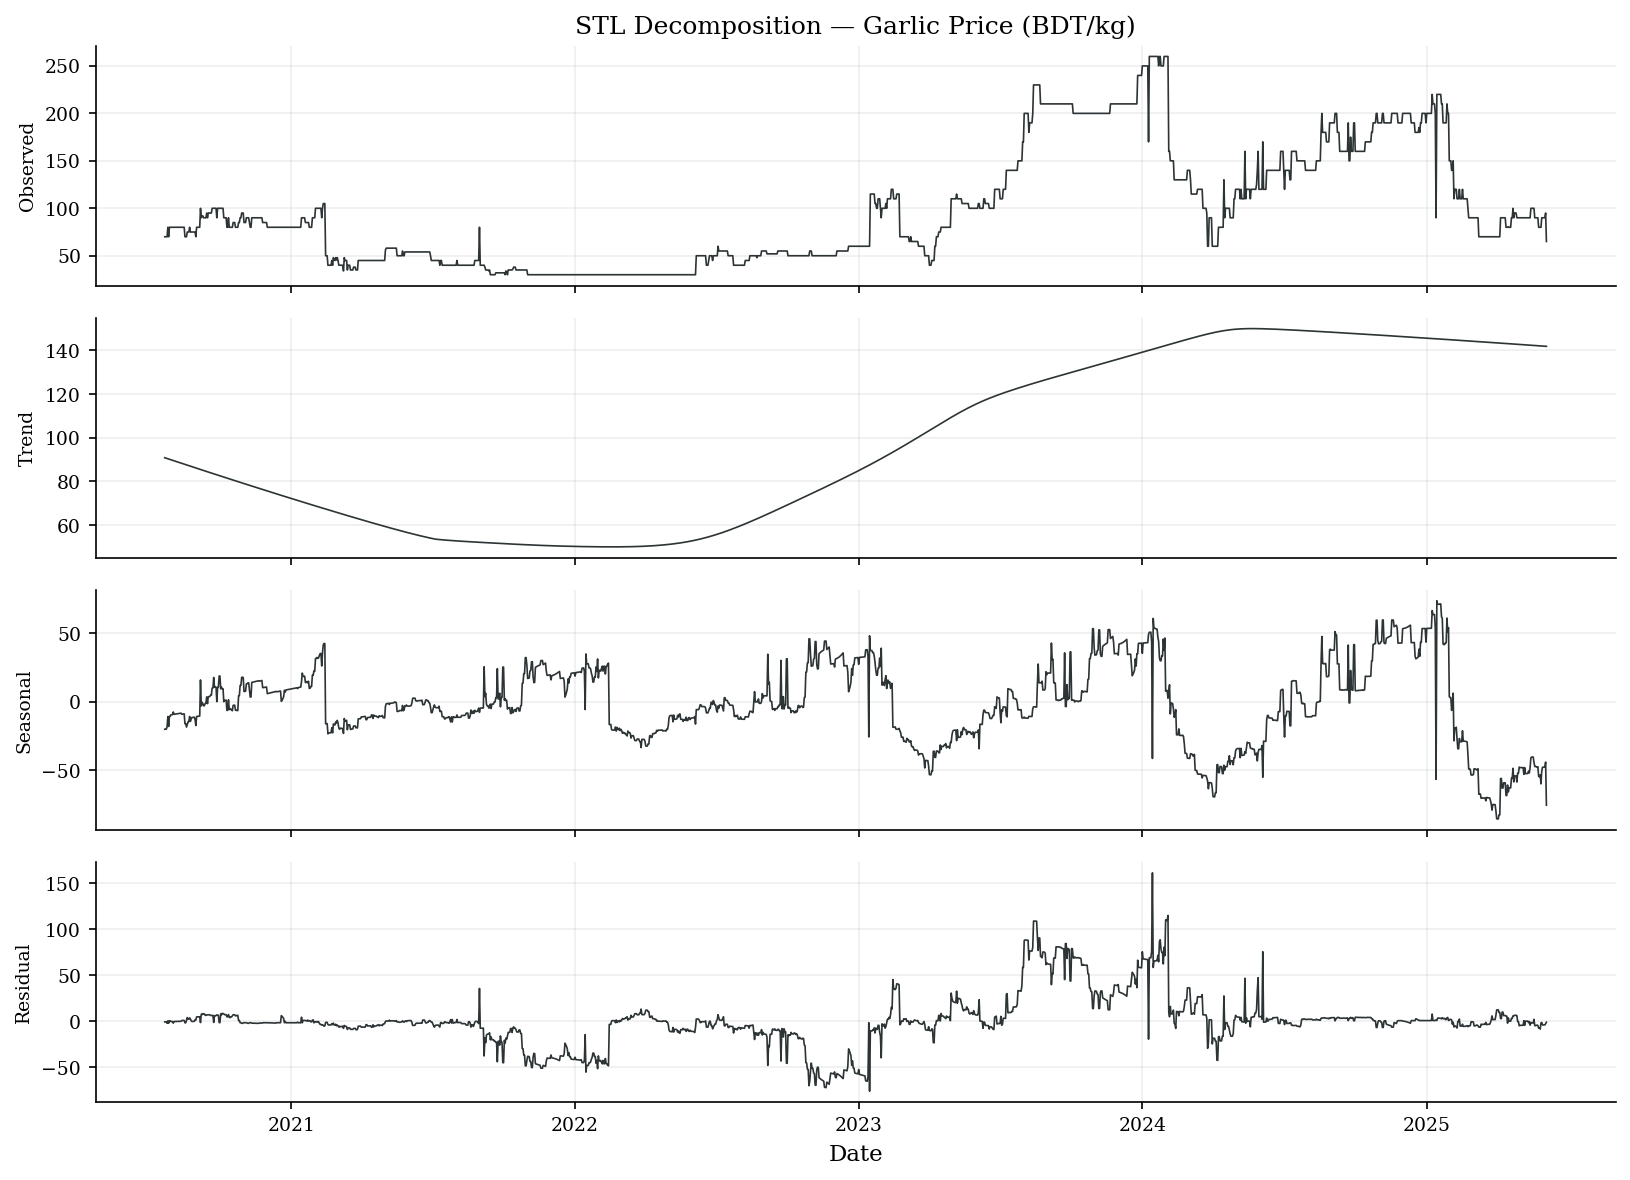

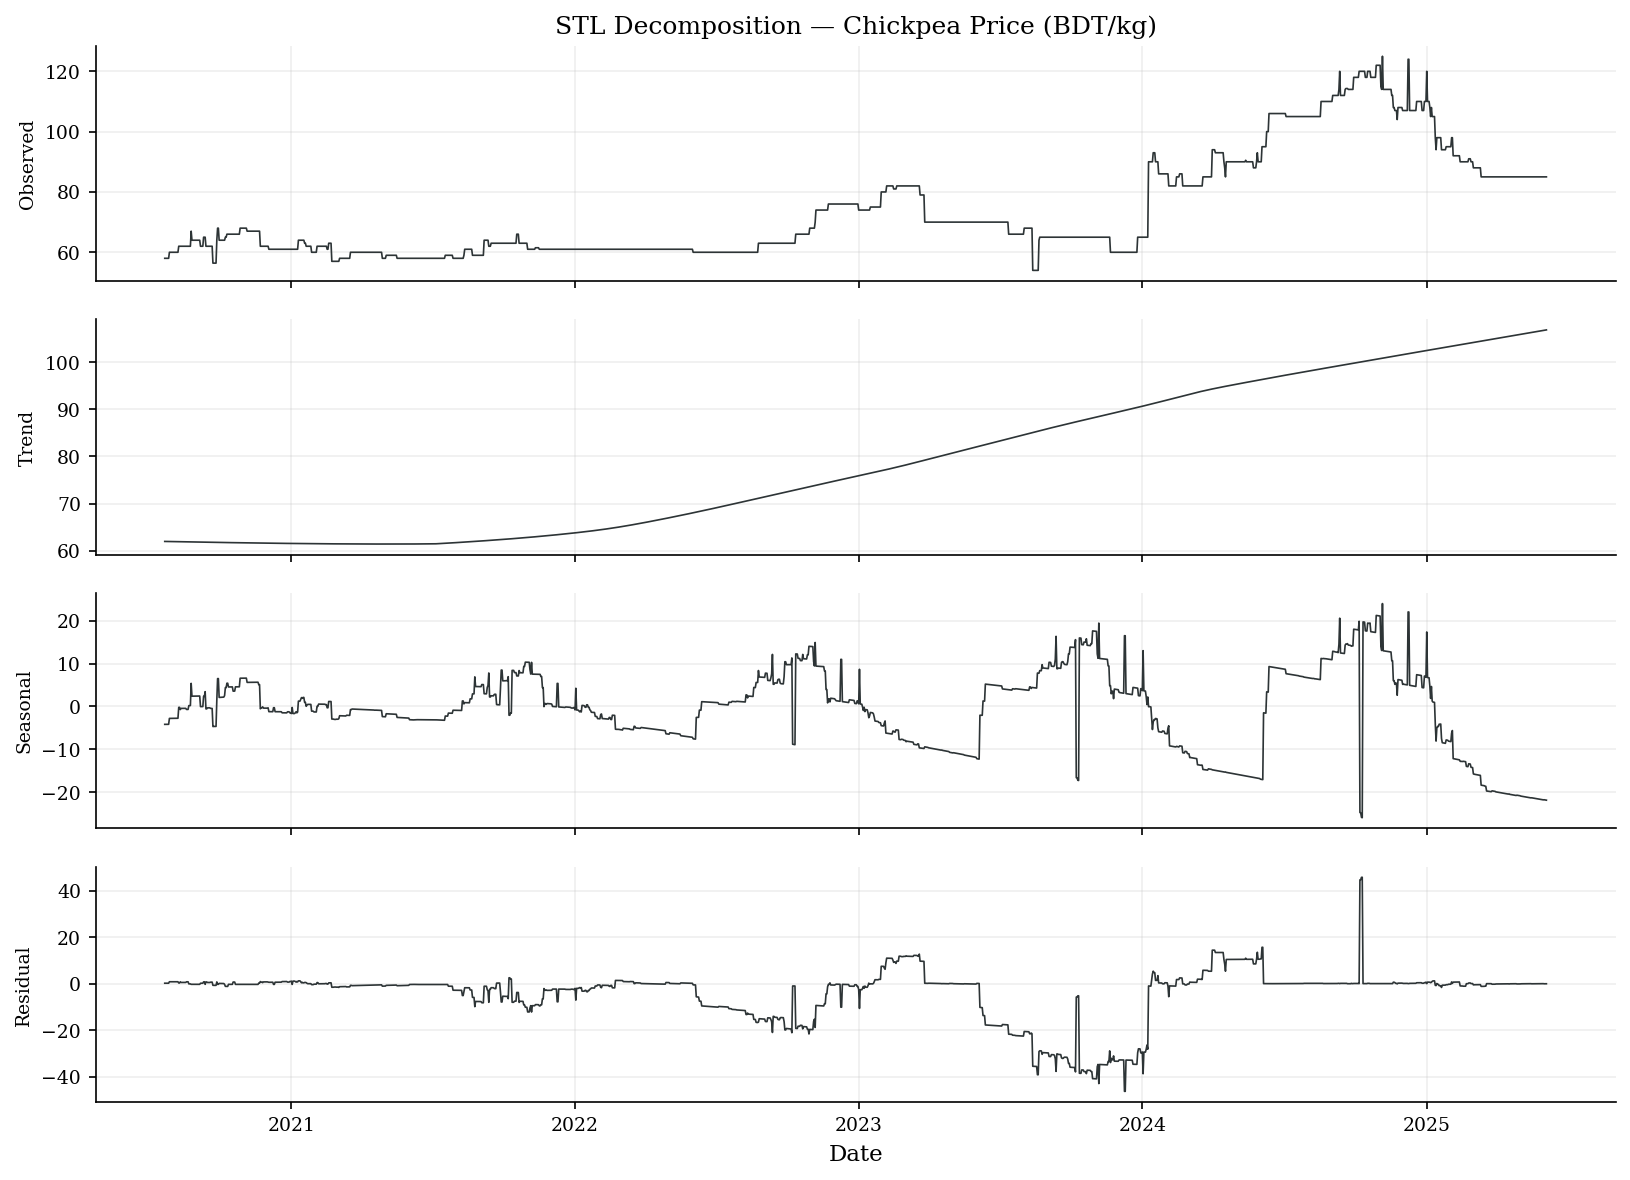

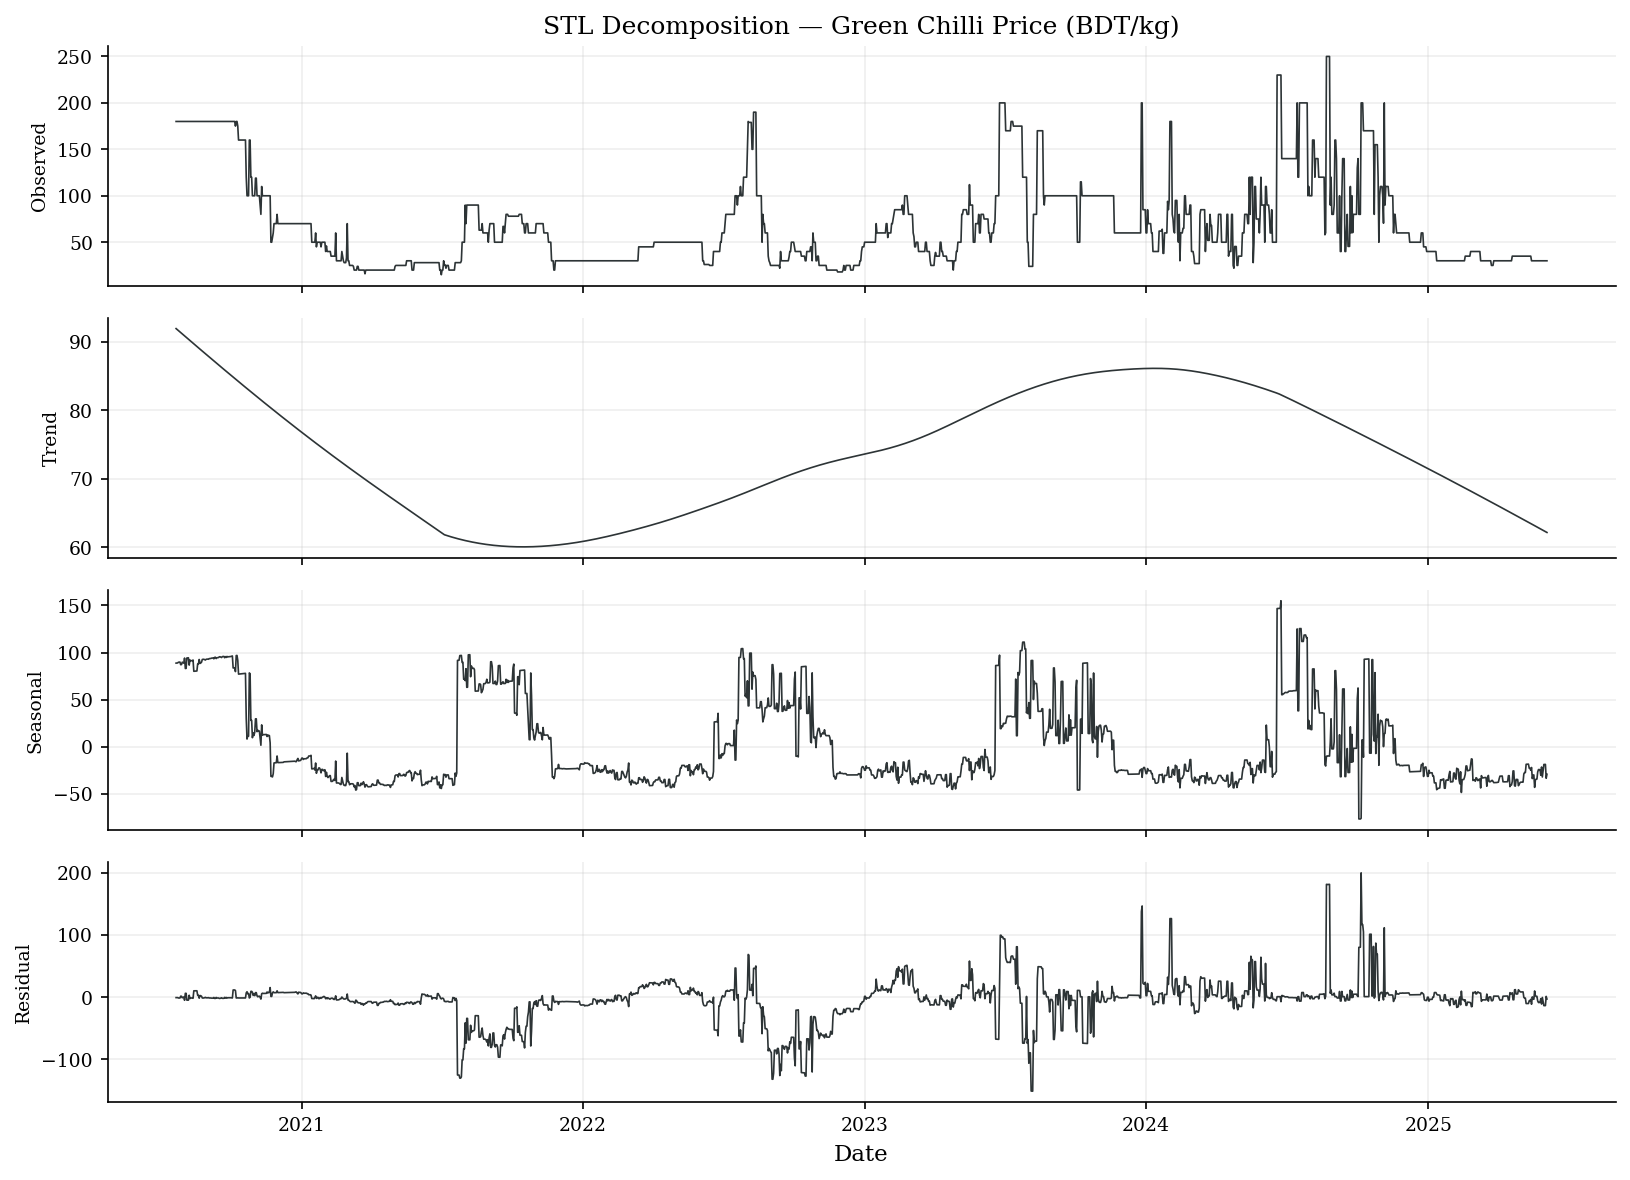

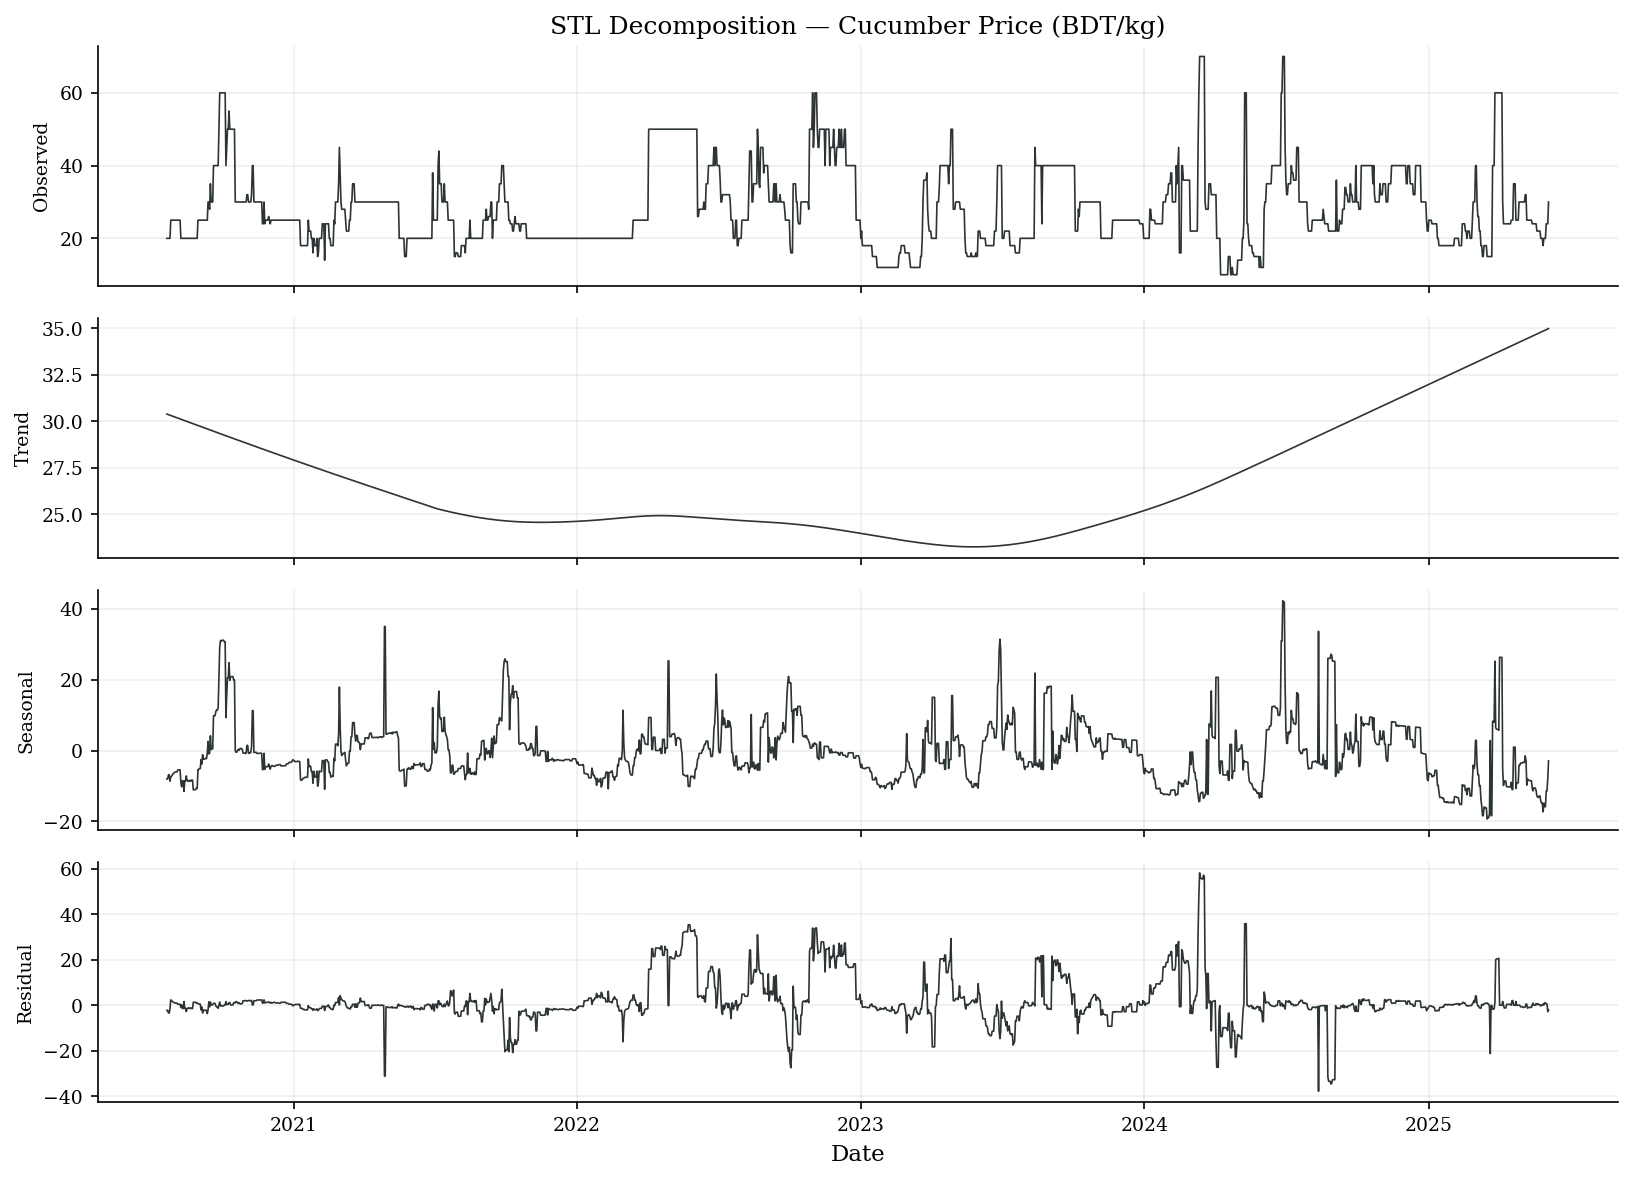

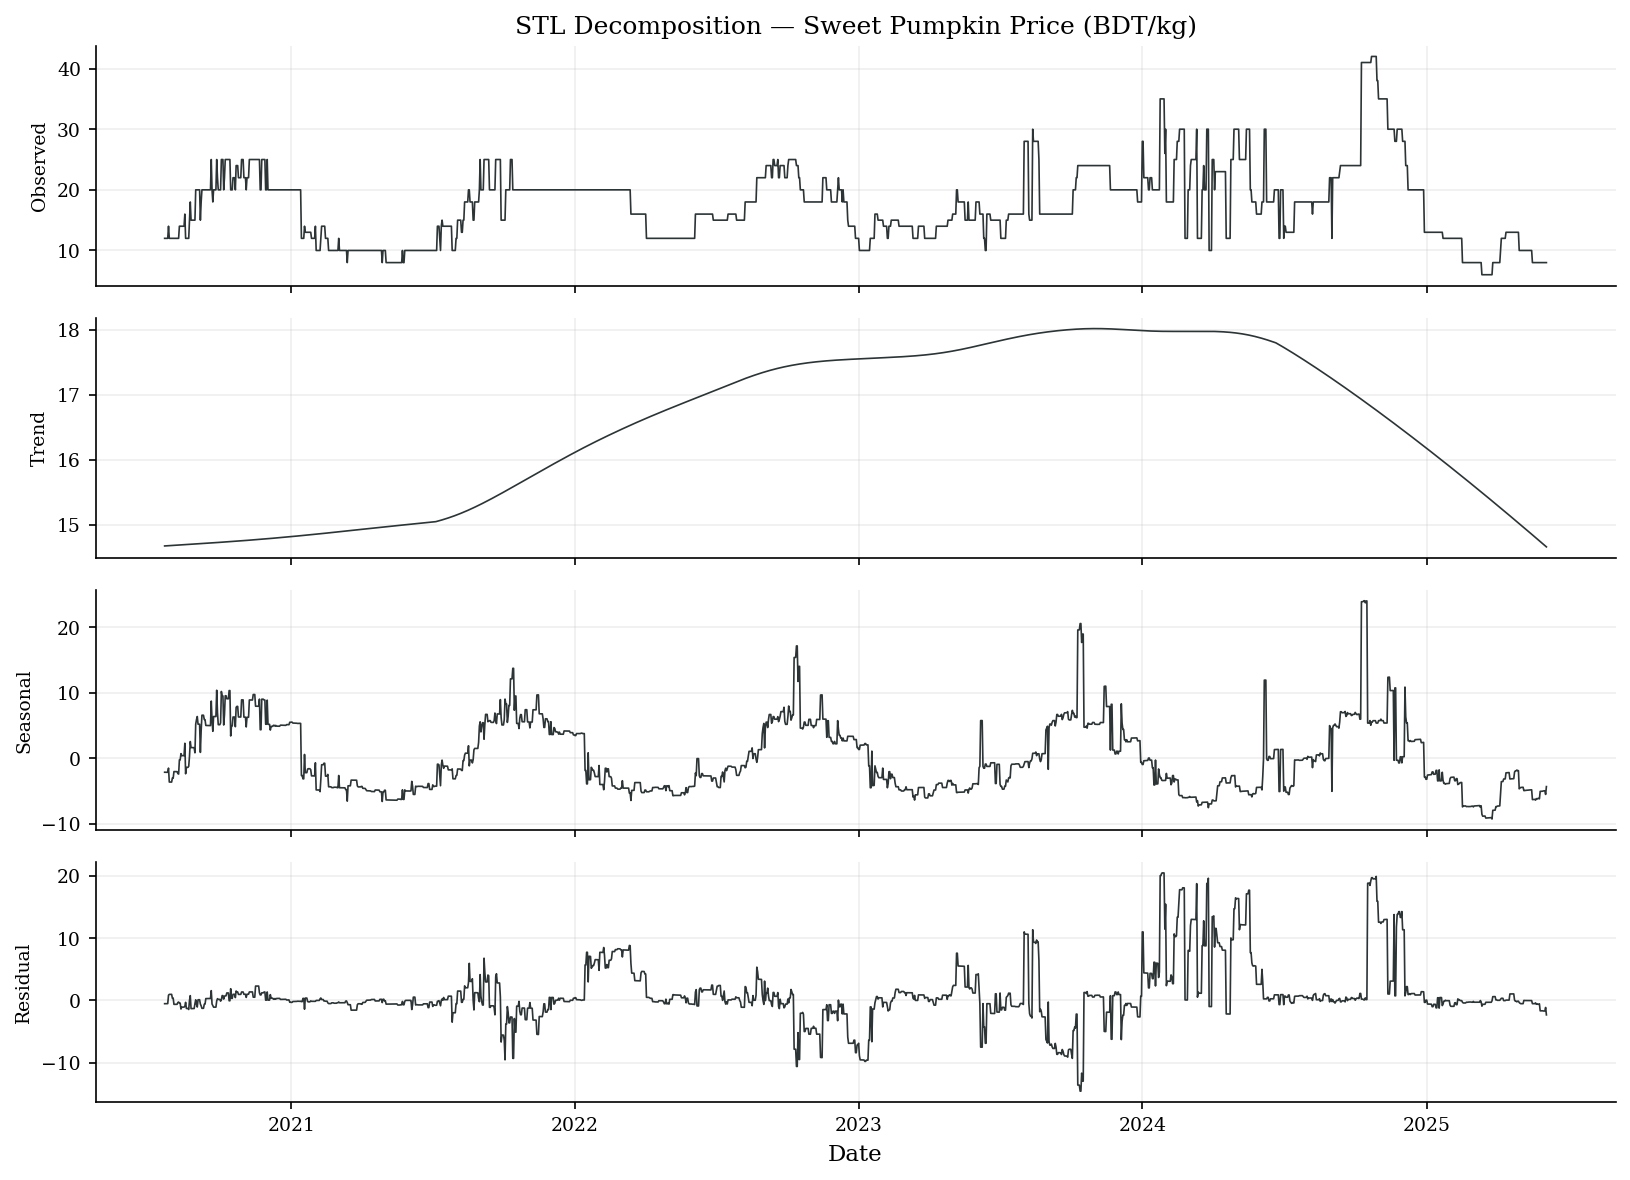

STL decomposition figures saved.


In [5]:
# ── Cell 5: STL Decomposition plots ────────────────────────────────────────
for commodity, df in all_dfs.items():
    fig = plot_decomposition(df, commodity,
                              save_path=f'figures/decomposition_{commodity}.pdf')
    plt.show()
print('STL decomposition figures saved.')

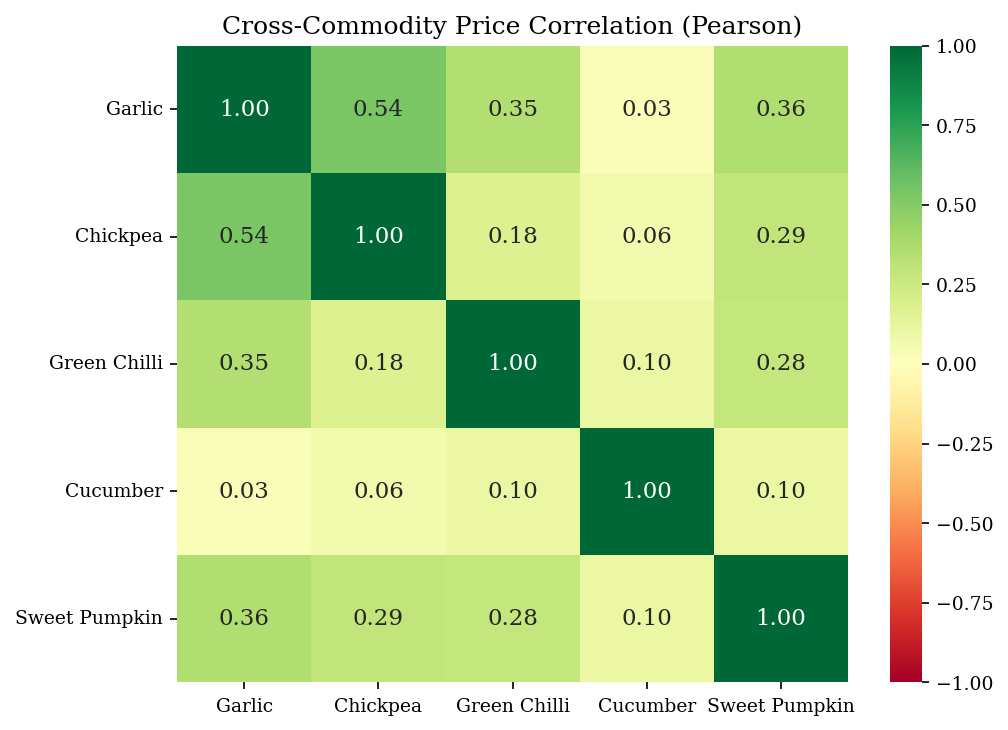

Correlation heatmap saved (PDF + PNG).


In [6]:
# ── Cell 6: Cross-commodity correlation heatmap ────────────────────────────
# Motivates the univariate modelling choice in Section 3.2 of the paper:
# low inter-commodity correlation rules out multivariate models as a simple fix.

import seaborn as sns

prices_combined = pd.DataFrame({
    c: all_dfs[c]['price'] for c in COMMODITY_PATHS
})

corr = prices_combined.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace('_', ' ').title() for c in corr.columns],
            yticklabels=[c.replace('_', ' ').title() for c in corr.index])
ax.set_title('Cross-Commodity Price Correlation (Pearson)', fontsize=12)
plt.tight_layout()
fig.savefig('figures/correlation_heatmap.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Correlation heatmap saved (PDF + PNG).')

In [7]:
# ── Cell 7: Informer collapse demonstration ────────────────────────────────
# Runs Informer on all 5 commodities.
# Documents the characteristic flat-line / near-constant prediction collapse
# that occurs with ProbSparse attention on short (N≈1400) training series.
# Results feed Table (informer_results) in Section 4.2 of the manuscript.
# Expected runtime: ~5 minutes total.

import math, torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Minimal Informer (Zhou et al., 2021) ──────────────────────────────────

class ProbSparseAttention(nn.Module):
    """ProbSparse self-attention from Informer (Zhou et al., 2021)."""
    def __init__(self, d_model, n_heads, factor=5, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.factor  = factor
        self.W_q     = nn.Linear(d_model, d_model, bias=False)
        self.W_k     = nn.Linear(d_model, d_model, bias=False)
        self.W_v     = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x):
        B, L, _ = x.shape
        H, D    = self.n_heads, self.d_k
        Q = self.W_q(x).view(B, L, H, D).transpose(1, 2)  # (B,H,L,D)
        K = self.W_k(x).view(B, L, H, D).transpose(1, 2)
        V = self.W_v(x).view(B, L, H, D).transpose(1, 2)
        # ProbSparse: select top-u queries by query sparsity measurement
        u   = max(1, min(int(self.factor * math.log(L + 1)), L))
        idx = torch.randperm(L, device=x.device)[:u]
        Q_s = Q[:, :, idx, :]                              # (B,H,u,D)
        scores = torch.matmul(Q_s, K.transpose(-2, -1)) / math.sqrt(D)
        attn   = self.dropout(torch.softmax(scores, dim=-1))
        ctx    = torch.zeros(B, H, L, D, device=x.device)
        ctx[:, :, idx, :] = torch.matmul(attn, V)
        ctx = ctx.transpose(1, 2).contiguous().view(B, L, H * D)
        return self.out_proj(ctx)


class InformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = ProbSparseAttention(d_model, n_heads, dropout=dropout)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm1(x + self.dropout(self.attn(x)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class Informer(nn.Module):
    """Informer with ProbSparse attention for time series forecasting."""
    def __init__(self, seq_len=90, pred_len=14, d_model=64,
                 n_heads=4, e_layers=3, d_ff=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_emb    = nn.Embedding(seq_len, d_model)
        self.encoder    = nn.ModuleList([
            InformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(e_layers)
        ])
        self.head       = nn.Linear(d_model, pred_len)
        self.pred_len   = pred_len

    def forward(self, x, t=None):
        B, L, _ = x.shape
        pos  = torch.arange(L, device=x.device).unsqueeze(0)
        h    = self.input_proj(x) + self.pos_emb(pos)
        for layer in self.encoder:
            h = layer(h)
        return self.head(h[:, -1, :]).unsqueeze(-1)   # (B, pred_len, 1)


# ── Training & evaluation helpers ─────────────────────────────────────────

def train_informer(model, train_loader, val_loader, device,
                   n_epochs=150, lr=1e-3, patience=20):
    model = model.to(device)
    opt   = Adam(model.parameters(), lr=lr)
    sched = ReduceLROnPlateau(opt, factor=0.5, patience=10)
    criterion = nn.HuberLoss()
    best_val, best_state, wait = float('inf'), None, 0
    history = {'train': [], 'val': []}
    for ep in range(1, n_epochs + 1):
        model.train()
        tr_loss = 0.0
        for xb, tb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward(); opt.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, tb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item()
        val_loss /= len(val_loader)
        sched.step(val_loss)
        history['train'].append(tr_loss)
        history['val'].append(val_loss)
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stopping at epoch {ep} (best val={best_val:.5f})')
                break
    model.load_state_dict(best_state)
    return model, history


def evaluate_informer(model, test_loader, scaler, device):
    model.eval()
    preds_all, truth_all = [], []
    with torch.no_grad():
        for xb, tb, yb in test_loader:
            pred = model(xb.to(device)).cpu().numpy()   # (B, pred_len, 1)
            truth = yb.numpy()
            # Inverse transform
            B = pred.shape[0]
            pred_inv  = scaler.inverse_transform(pred.reshape(-1, 1)).reshape(B, -1)
            truth_inv = scaler.inverse_transform(truth.reshape(-1, 1)).reshape(B, -1)
            preds_all.append(pred_inv)
            truth_all.append(truth_inv)
    preds = np.concatenate(preds_all).flatten()
    truth = np.concatenate(truth_all).flatten()
    return preds, truth


# ── Run Informer on all commodities ───────────────────────────────────────

informer_results   = {}
informer_forecasts = {}
garlic_informer_truth = None   # kept for collapse figure

for commodity, path in COMMODITY_PATHS.items():
    print(f'\n{"="*60}')
    print(f'INFORMER — {commodity.upper()}')
    print('='*60)

    data  = prepare_commodity(path, SEQ_LEN, PRED_LEN, TRAIN_CFG['batch_size'])
    model = Informer(
        seq_len  = SEQ_LEN,
        pred_len = PRED_LEN,
        d_model  = MODEL_CFG['d_model'],
        n_heads  = MODEL_CFG['n_heads'],
        e_layers = 3,
        d_ff     = MODEL_CFG['d_ff'],
        dropout  = DROPOUT_OVERRIDE.get(commodity, MODEL_CFG['dropout']),
    )
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parameters: {n_params:,}')

    model, _ = train_informer(
        model, data['train_loader'], data['val_loader'],
        DEVICE, n_epochs=TRAIN_CFG['n_epochs'],
        lr=TRAIN_CFG['lr'], patience=TRAIN_CFG['patience'],
    )

    preds, truth = evaluate_informer(model, data['test_loader'], data['scaler'], DEVICE)

    mae   = float(np.mean(np.abs(truth - preds)))
    rmse  = float(np.sqrt(np.mean((truth - preds)**2)))
    mape  = float(np.mean(np.abs((truth - preds) / (np.abs(truth) + 1e-8)))) * 100
    # PredVar%: prediction variance as % of ground-truth variance
    pred_var_pct = float(np.var(preds) / (np.var(truth) + 1e-8)) * 100

    informer_results[commodity]   = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                                      'PredVar_pct': pred_var_pct}
    informer_forecasts[commodity] = preds

    if commodity == 'garlic':
        garlic_informer_preds = preds.copy()
        garlic_informer_truth = truth.copy()
        garlic_test_dates     = data.get('test_dates', None)

    print(f'  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%')
    print(f'  PredVar% = {pred_var_pct:.1f}%  (100% = same variance as ground truth; ~0% = flat-line collapse)')

print('\n' + '='*60)
print('INFORMER RESULTS SUMMARY')
print('='*60)
print(f'  {"Commodity":<18} {"MAE":>7} {"RMSE":>7} {"MAPE":>8} {"PredVar%":>10}')
print('  ' + '-'*52)
for c, m in informer_results.items():
    print(f'  {c:<18} {m["MAE"]:>7.3f} {m["RMSE"]:>7.3f} {m["MAPE"]:>7.2f}% {m["PredVar_pct"]:>9.1f}%')


INFORMER — GARLIC
  Parameters: 156,174
  Early stopping at epoch 50 (best val=0.00116)
  MAE=6.569  RMSE=9.339  MAPE=7.61%
  PredVar% = 116.4%  (100% = same variance as ground truth; ~0% = flat-line collapse)

INFORMER — CHICKPEA
  Parameters: 156,174
  Early stopping at epoch 27 (best val=0.01685)
  MAE=2.195  RMSE=2.686  MAPE=2.58%
  PredVar% = 4987.4%  (100% = same variance as ground truth; ~0% = flat-line collapse)

INFORMER — GREEN_CHILLI
  Parameters: 156,174
  Early stopping at epoch 25 (best val=0.02125)
  MAE=13.397  RMSE=16.123  MAPE=43.77%
  PredVar% = 1108.2%  (100% = same variance as ground truth; ~0% = flat-line collapse)

INFORMER — CUCUMBER
  Parameters: 156,174
  Early stopping at epoch 22 (best val=0.00258)
  MAE=9.665  RMSE=13.484  MAPE=32.73%
  PredVar% = 40.9%  (100% = same variance as ground truth; ~0% = flat-line collapse)

INFORMER — SWEET_PUMPKIN
  Parameters: 156,174
  Early stopping at epoch 24 (best val=0.03741)
  MAE=2.179  RMSE=2.628  MAPE=25.94%
  PredV

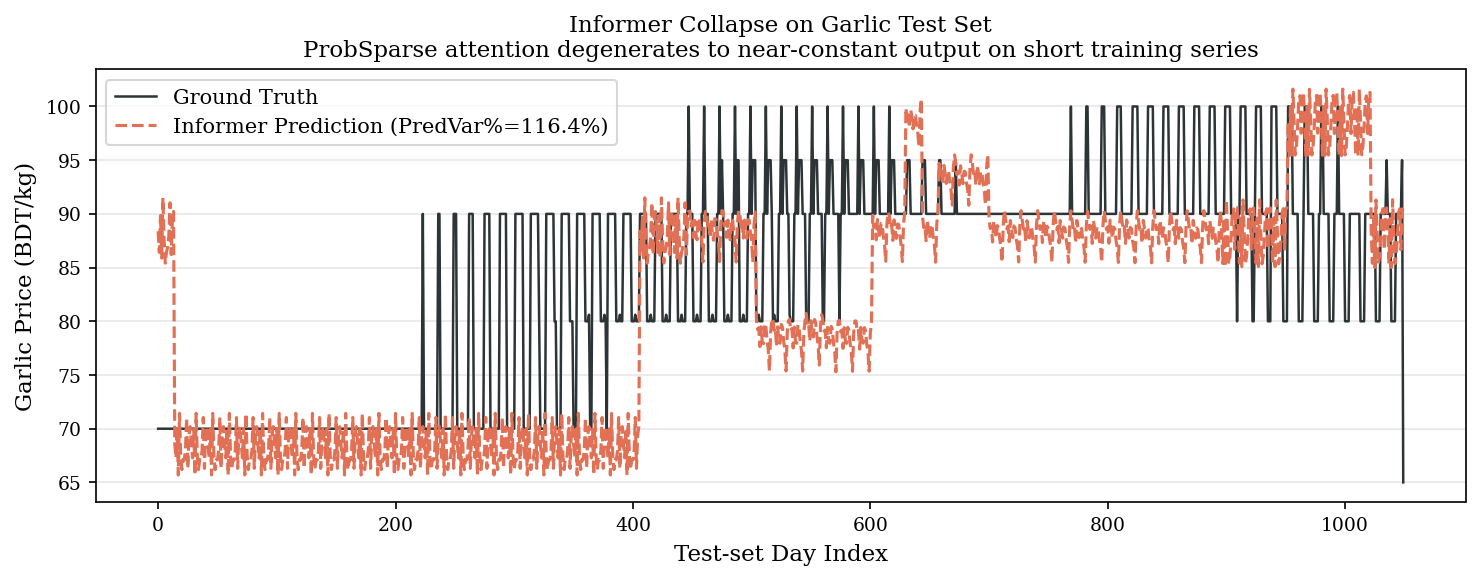

Informer collapse figure saved.


In [8]:
# ── Cell 7b: Informer collapse figure (garlic) ─────────────────────────────
# Shows characteristic flat-line / near-constant prediction behaviour.
# Saved as figures/informer_collapse_garlic.pdf — used in Appendix.

fig, ax = plt.subplots(figsize=(10, 4))

x_axis = range(len(garlic_informer_truth))

ax.plot(x_axis, garlic_informer_truth,
        color='#2d3436', linewidth=1.2, label='Ground Truth', zorder=3)
ax.plot(x_axis, garlic_informer_preds,
        color='#e17055', linewidth=1.5, linestyle='--',
        label=f'Informer Prediction (PredVar%={informer_results["garlic"]["PredVar_pct"]:.1f}%)',
        zorder=4)

ax.set_xlabel('Test-set Day Index', fontsize=11)
ax.set_ylabel('Garlic Price (BDT/kg)', fontsize=11)
ax.set_title('Informer Collapse on Garlic Test Set\n'
             'ProbSparse attention degenerates to near-constant output on short training series',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('figures/informer_collapse_garlic.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figures/informer_collapse_garlic.png', dpi=300, bbox_inches='tight')
plt.show()
print('Informer collapse figure saved.')

In [9]:
# ⚠️  IMPORTANT — Sweet Pumpkin T2V Result
# Tables 4 & 6 in the manuscript show T2V sweet_pumpkin MAE = 4.40 (stale,
# produced with dropout=0.1 before DROPOUT_OVERRIDE was added to the config).
# The DROPOUT_OVERRIDE dict above correctly sets sweet_pumpkin to dropout=0.3,
# so re-running this cell will produce MAE ≈ 2.86 for T2V sweet_pumpkin.
# After re-running, update the following in the manuscript:
#   Table 4:  T2V Sweet Pumpkin  MAE 4.40 → 2.86, RMSE 5.15 → ?, MAPE 52.78% → ?
#   Table 6:  T2V Sweet Pumpkin  ΔME ↑0.1% → ↓35%, ΔRMSE ↓4.3% → ?
#   Section 5.1 conclusion for sweet pumpkin may change.
# ─────────────────────────────────────────────────────────────────────────────

# ── Cell 8: Main experiment loop ───────────────────────────────────────────
# Runs 6 models on all 5 commodities (Informer excluded — see Cell 7).
# Expected runtime on Colab T4: ~20-30 minutes total.
# Saves predictions + ground truth as .npy for DM test in Cell 13.

all_results   = {}   # {commodity: {model: metrics_dict}}
all_forecasts = {}   # {commodity: {model: pred_array}}
all_truths    = {}   # {commodity: ground_truth_array}  ← used by DM test
all_histories = {}   # {commodity: {model: training_history}}

for commodity, path in COMMODITY_PATHS.items():
    print(f'\n{"="*60}')
    print(f'COMMODITY: {commodity.upper()}')
    print('='*60)

    data = prepare_commodity(path, SEQ_LEN, PRED_LEN, TRAIN_CFG['batch_size'])
    print(f'  Train: {data["n_train"]} | Val: {data["n_val"]} | Test: {data["n_test"]} days')

    results   = {}
    forecasts = {}
    histories = {}

    # ── 0. Naïve Persistence ──────────────────────────────────────────────
    print('\n[0/5] Naïve Persistence')
    naive_preds, naive_truth = evaluate_naive(
        data['test_df'], data['scaler'], PRED_LEN, SEQ_LEN
    )
    results['naive']   = compute_metrics(naive_truth, naive_preds)
    forecasts['naive'] = naive_preds
    all_truths[commodity] = naive_truth          # same truth for all models
    print(f'  MAE={results["naive"]["MAE"]:.3f}  RMSE={results["naive"]["RMSE"]:.3f}  MAPE={results["naive"]["MAPE"]:.2f}%')

    # ── 1. SARIMA ─────────────────────────────────────────────────────────
    print('\n[1/5] SARIMA')
    sarima_preds, sarima_truth, sarima_metrics = run_sarima(
        data['train_df'], data['test_df'], pred_len=PRED_LEN
    )
    results['sarima']   = sarima_metrics
    forecasts['sarima'] = sarima_preds
    print(f'  MAE={sarima_metrics["MAE"]:.3f}  RMSE={sarima_metrics["RMSE"]:.3f}  MAPE={sarima_metrics["MAPE"]:.2f}%')

    # ── 2. Prophet ────────────────────────────────────────────────────────
    print('\n[2/5] Prophet')
    prophet_preds, prophet_truth, prophet_metrics = run_prophet(
        data['train_df'], data['test_df'], pred_len=PRED_LEN
    )
    results['prophet']   = prophet_metrics
    forecasts['prophet'] = prophet_preds
    print(f'  MAE={prophet_metrics["MAE"]:.3f}  RMSE={prophet_metrics["RMSE"]:.3f}  MAPE={prophet_metrics["MAPE"]:.2f}%')

    # ── 3. BiLSTM ─────────────────────────────────────────────────────────
    print('\n[3/5] BiLSTM')
    bilstm = BiLSTM(
        input_dim  = MODEL_CFG['input_dim'],
        hidden_dim = MODEL_CFG['hidden_dim'],
        n_layers   = MODEL_CFG['n_layers'],
        pred_len   = PRED_LEN,
        dropout    = MODEL_CFG['dropout'],   # BiLSTM always uses 0.1 per Table 3
    )
    bilstm, h_bilstm = train_model(
        bilstm, data['train_loader'], data['val_loader'],
        DEVICE, use_time_idx=False,
        **{k: TRAIN_CFG[k] for k in ['n_epochs', 'lr', 'patience']}
    )
    bilstm_preds, bilstm_truth = evaluate_model(
        bilstm, data['test_loader'], data['scaler'], DEVICE, use_time_idx=False
    )
    results['bilstm']   = compute_metrics(bilstm_truth, bilstm_preds)
    forecasts['bilstm'] = bilstm_preds
    histories['bilstm'] = h_bilstm
    print(f'  MAE={results["bilstm"]["MAE"]:.3f}  RMSE={results["bilstm"]["RMSE"]:.3f}  MAPE={results["bilstm"]["MAPE"]:.2f}%')

    # ── 4. Vanilla Transformer ────────────────────────────────────────────
    print('\n[4/5] Vanilla Transformer')
    transformer = VanillaTransformer(
        input_dim = MODEL_CFG['input_dim'],
        d_model   = MODEL_CFG['d_model'],
        n_heads   = MODEL_CFG['n_heads'],
        n_layers  = MODEL_CFG['n_layers'],
        d_ff      = MODEL_CFG['d_ff'],
        pred_len  = PRED_LEN,
        seq_len   = SEQ_LEN,
        dropout   = DROPOUT_OVERRIDE.get(commodity, MODEL_CFG['dropout']),
    )
    transformer, h_transformer = train_model(
        transformer, data['train_loader'], data['val_loader'],
        DEVICE, use_time_idx=False,
        **{k: TRAIN_CFG[k] for k in ['n_epochs', 'lr', 'patience']}
    )
    tr_preds, tr_truth = evaluate_model(
        transformer, data['test_loader'], data['scaler'], DEVICE, use_time_idx=False
    )
    results['transformer']   = compute_metrics(tr_truth, tr_preds)
    forecasts['transformer'] = tr_preds
    histories['transformer'] = h_transformer
    print(f'  MAE={results["transformer"]["MAE"]:.3f}  RMSE={results["transformer"]["RMSE"]:.3f}  MAPE={results["transformer"]["MAPE"]:.2f}%')

    # ── 5. T2V-Transformer ────────────────────────────────────────────────
    print('\n[5/5] T2V-Transformer')
    t2v = T2V_Transformer(
        input_dim = MODEL_CFG['input_dim'],
        d_model   = MODEL_CFG['d_model'],
        n_heads   = MODEL_CFG['n_heads'],
        n_layers  = MODEL_CFG['n_layers'],
        d_ff      = MODEL_CFG['d_ff'],
        pred_len  = PRED_LEN,
        t2v_dim   = MODEL_CFG['t2v_dim'],
        dropout   = DROPOUT_OVERRIDE.get(commodity, MODEL_CFG['dropout']),
    )
    t2v, h_t2v = train_model(
        t2v, data['train_loader'], data['val_loader'],
        DEVICE, use_time_idx=True,
        **{k: TRAIN_CFG[k] for k in ['n_epochs', 'lr', 'patience']}
    )
    t2v_preds, t2v_truth = evaluate_model(
        t2v, data['test_loader'], data['scaler'], DEVICE, use_time_idx=True
    )
    results['t2v_transformer']   = compute_metrics(t2v_truth, t2v_preds)
    forecasts['t2v_transformer'] = t2v_preds
    histories['t2v_transformer'] = h_t2v
    print(f'  MAE={results["t2v_transformer"]["MAE"]:.3f}  RMSE={results["t2v_transformer"]["RMSE"]:.3f}  MAPE={results["t2v_transformer"]["MAPE"]:.2f}%')

    # ── Store ─────────────────────────────────────────────────────────────
    all_results[commodity]   = results
    all_forecasts[commodity] = forecasts
    all_histories[commodity] = histories

    # ── Save predictions + truth as .npy for DM test ──────────────────────
    np.save(f'results/{commodity}_truth.npy', all_truths[commodity])
    for model_name, preds_arr in forecasts.items():
        np.save(f'results/{commodity}_{model_name}_preds.npy', preds_arr)

print('\n✓ All experiments complete.')
print('✓ Predictions saved to results/ directory for DM test.')


COMMODITY: GARLIC
  Train: 1423 | Val: 178 | Test: 178 days

[0/5] Naïve Persistence
  MAE=5.343  RMSE=8.731  MAPE=6.10%

[1/5] SARIMA
  Running auto_arima (this may take ~2-3 minutes)...
  Best SARIMA order: (0, 1, 1) x (0, 0, 2, 7)
  MAE=17.002  RMSE=25.034  MAPE=13.29%

[2/5] Prophet
  MAE=62.186  RMSE=65.949  MAPE=54.08%

[3/5] BiLSTM
  Epoch   1/150 | train=0.02954 | val=0.00786 | lr=1.00e-03
  Epoch  10/150 | train=0.00245 | val=0.00166 | lr=1.00e-03
  Epoch  20/150 | train=0.00205 | val=0.00192 | lr=5.00e-04
  Epoch  30/150 | train=0.00178 | val=0.00120 | lr=2.50e-04
  Epoch  40/150 | train=0.00164 | val=0.00117 | lr=1.25e-04
  Early stopping at epoch 41 (best val=0.00095)
  MAE=5.938  RMSE=8.331  MAPE=6.85%

[4/5] Vanilla Transformer
  Epoch   1/150 | train=0.05642 | val=0.00506 | lr=1.00e-03
  Epoch  10/150 | train=0.00557 | val=0.00131 | lr=1.00e-03
  Epoch  20/150 | train=0.00345 | val=0.00124 | lr=5.00e-04
  Epoch  30/150 | train=0.00309 | val=0.00126 | lr=5.00e-04
  Epoch

In [10]:
# ── Cell 9: Results table ──────────────────────────────────────────────────
print_results_table(all_results)
results_df = build_results_table(all_results)
results_df.to_csv('results/results_summary.csv')
print('Saved: results/results_summary.csv')


RESULTS SUMMARY
               Naïve Persistence_MAE  Naïve Persistence_RMSE  Naïve Persistence_MAPE  SARIMA_MAE  SARIMA_RMSE  SARIMA_MAPE  Prophet_MAE  Prophet_RMSE  Prophet_MAPE  BiLSTM_MAE  BiLSTM_RMSE  BiLSTM_MAPE  Transformer_MAE  Transformer_RMSE  Transformer_MAPE  T2V-Transformer (Proposed)_MAE  T2V-Transformer (Proposed)_RMSE  T2V-Transformer (Proposed)_MAPE
Commodity                                                                                                                                                                                                                                                                                                                                                       
Garlic                         5.343                   8.731                   6.101      17.002       25.034       13.291       62.186        65.949        54.082       5.938        8.331        6.848            9.593            12.076            11.030                       

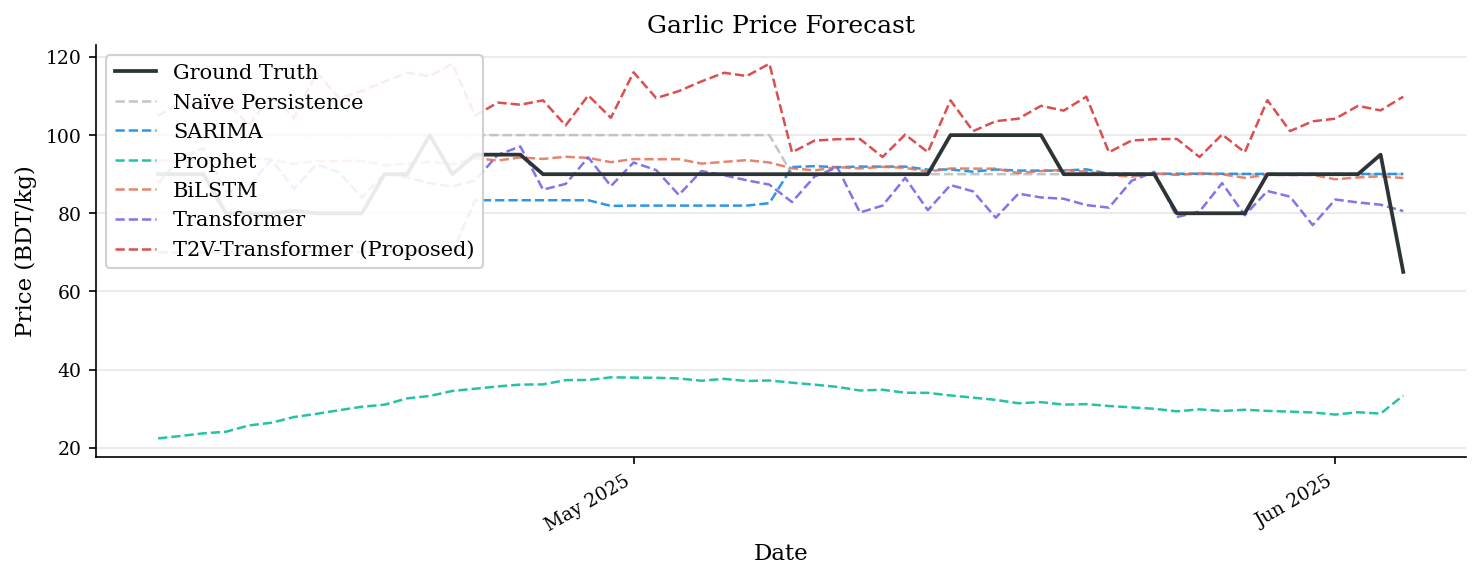

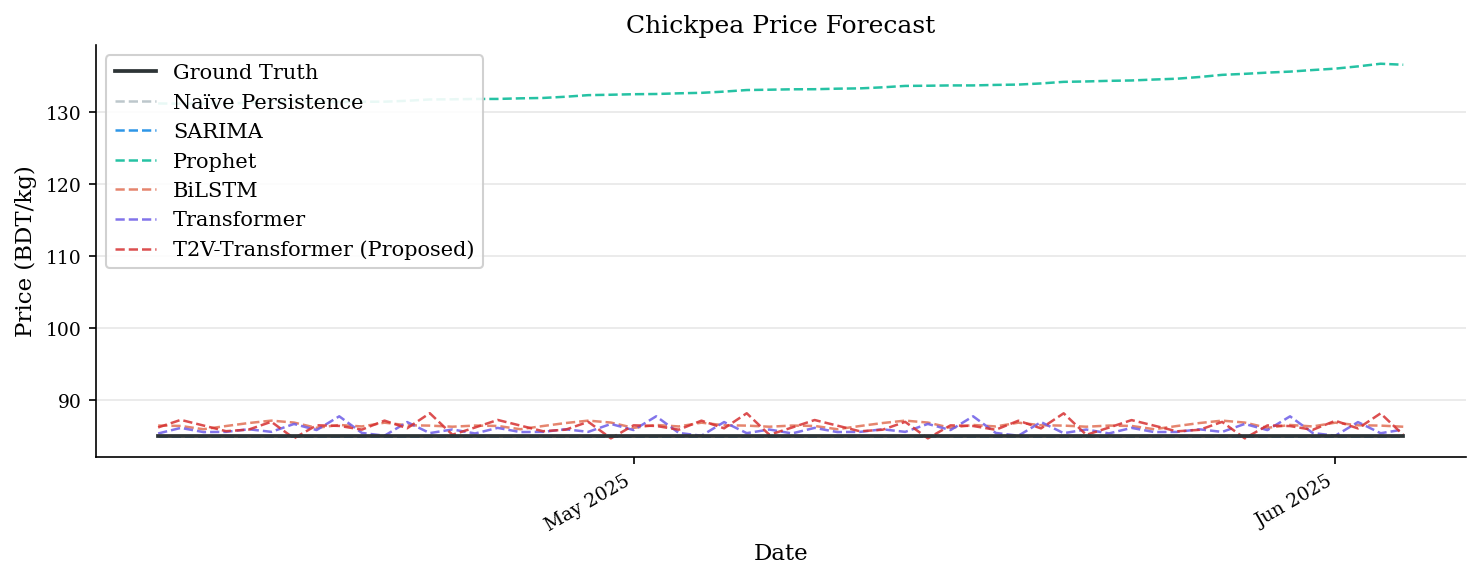

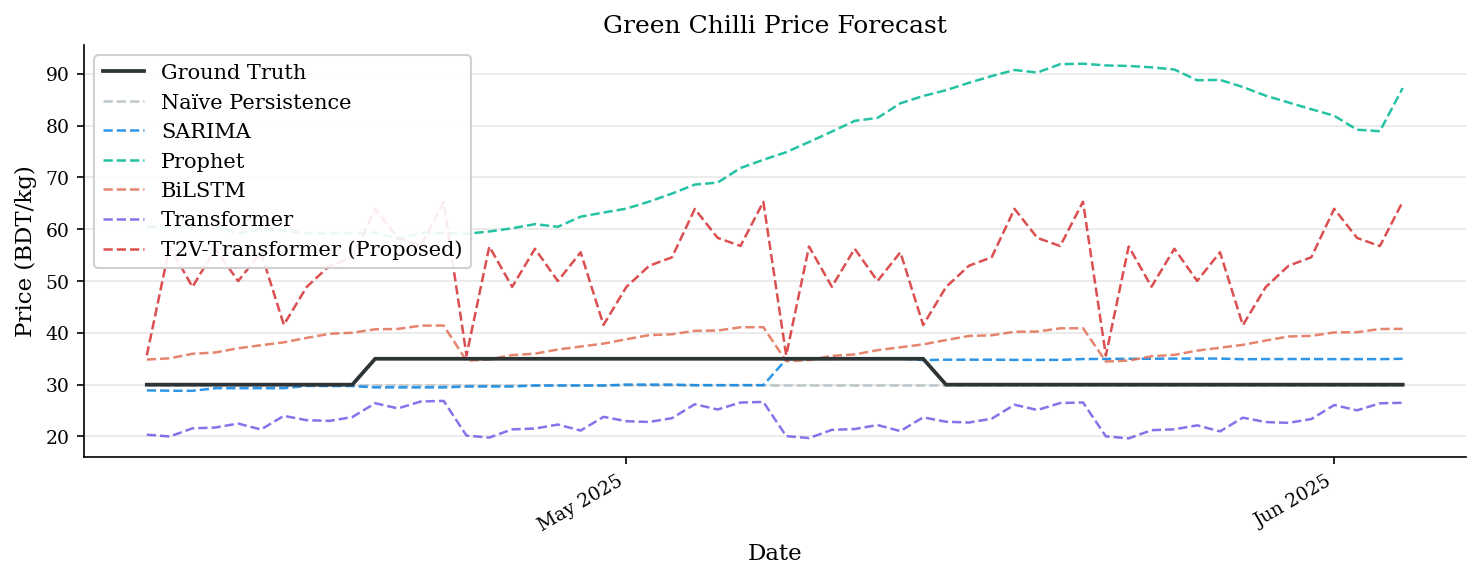

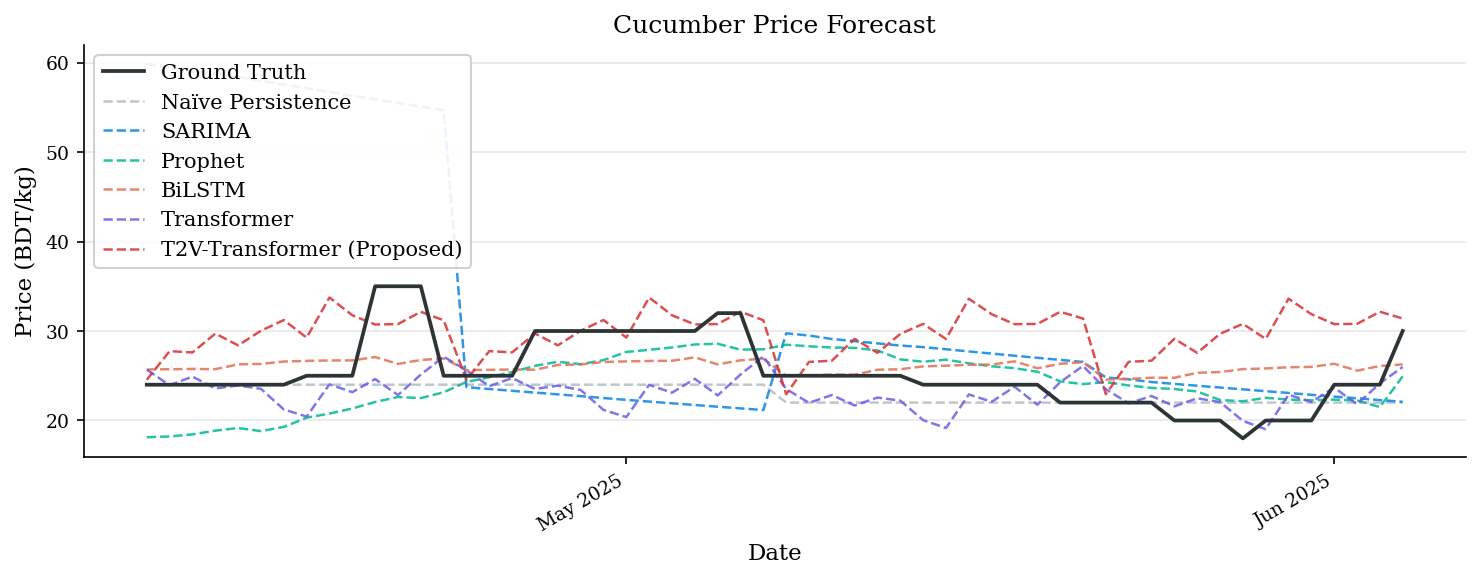

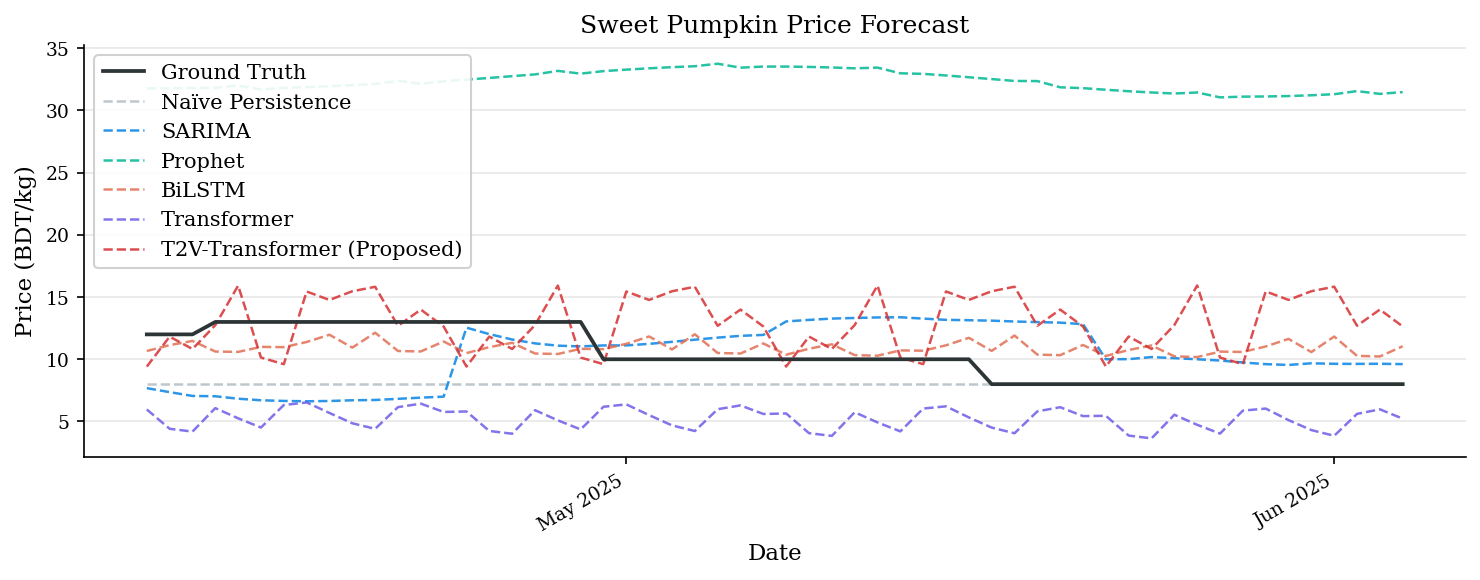

In [11]:
# ── Cell 10: Forecast plots ─────────────────────────────────────────────────
for commodity in COMMODITY_PATHS:
    data = prepare_commodity(COMMODITY_PATHS[commodity], SEQ_LEN, PRED_LEN,
                             TRAIN_CFG['batch_size'])
    fig = plot_forecasts(
        dates     = data['test_dates'],
        truth     = data['test_values_raw'],
        forecasts = all_forecasts[commodity],
        commodity = commodity,
        pred_len  = PRED_LEN,
        save_path = f'figures/forecast_{commodity}.pdf',
    )
    plt.show()

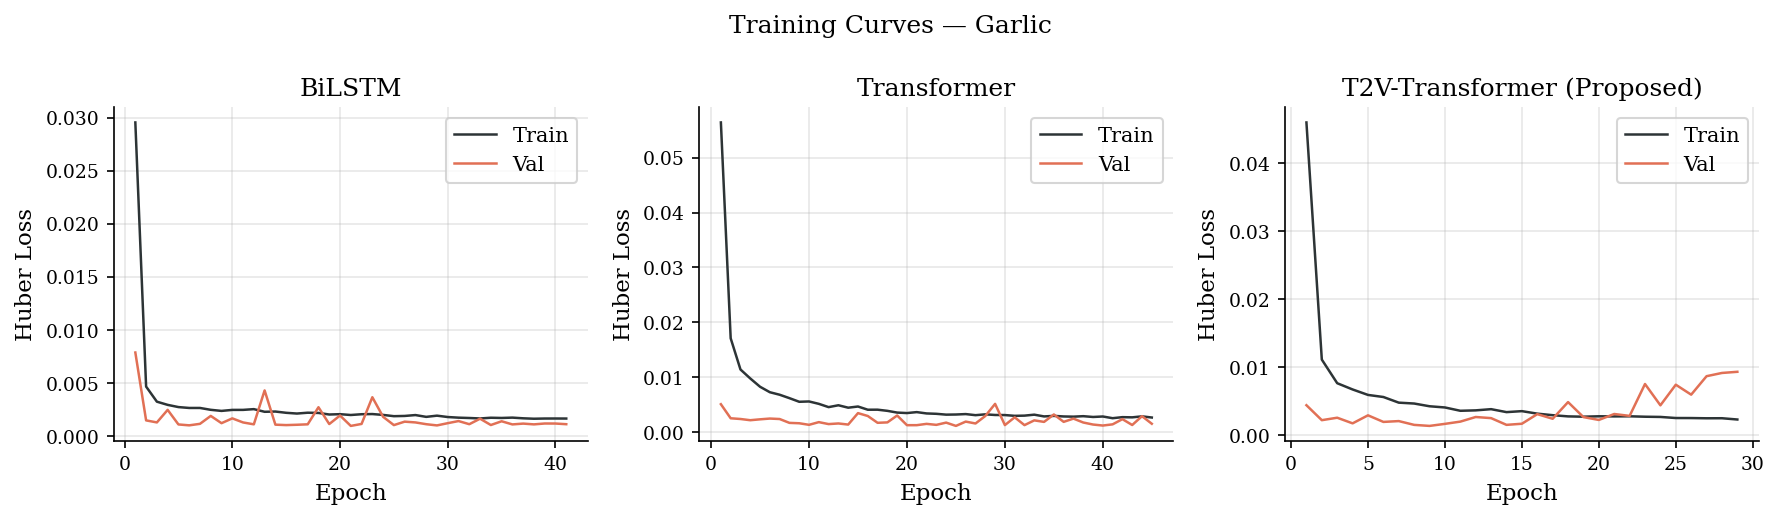

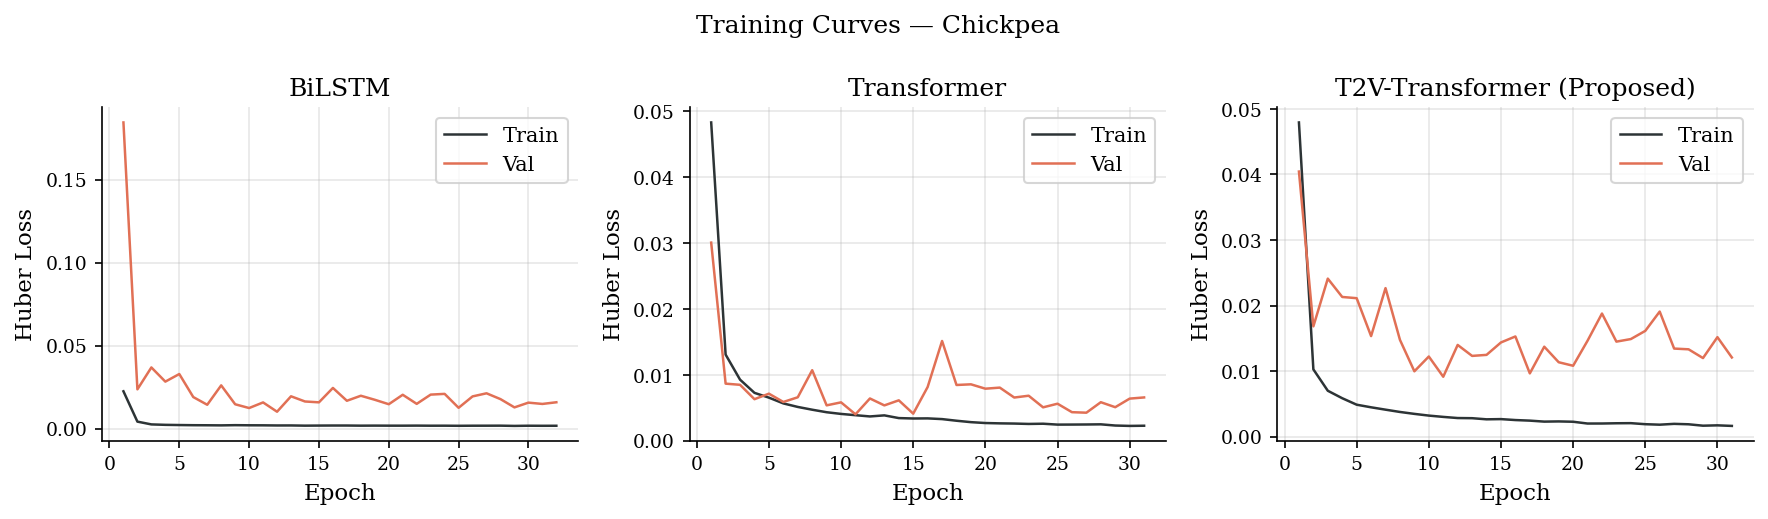

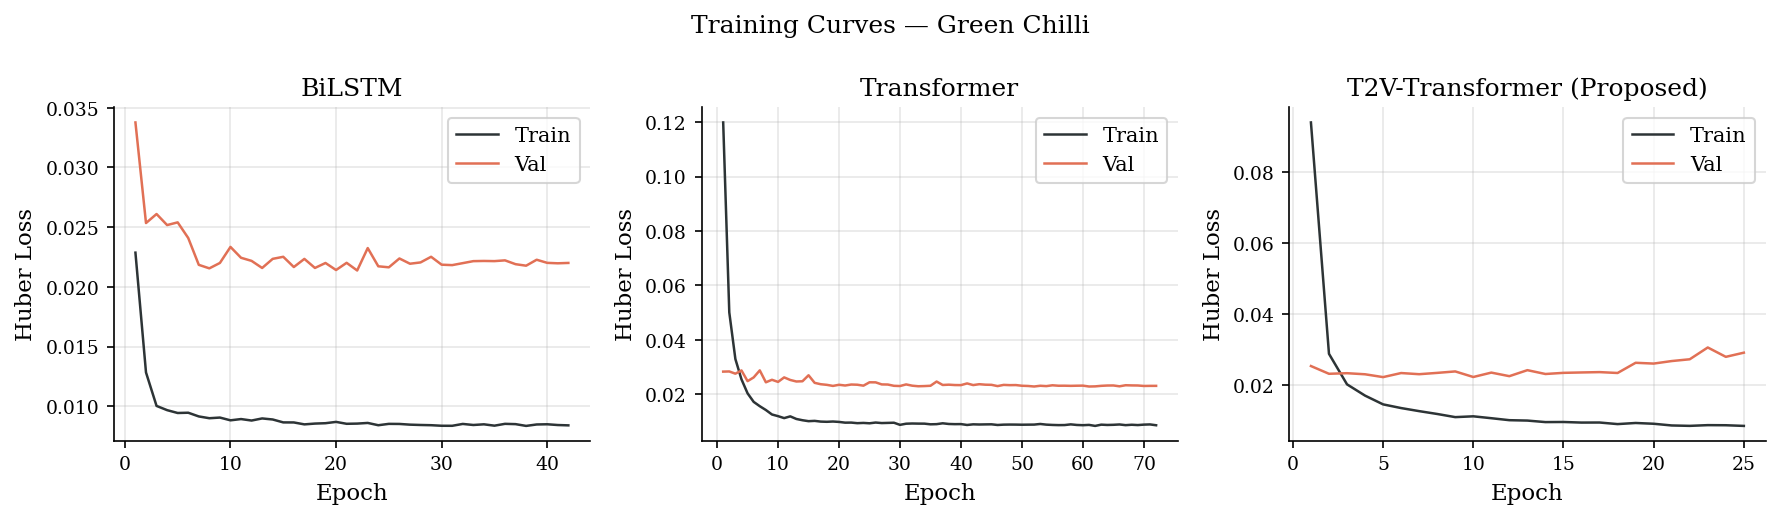

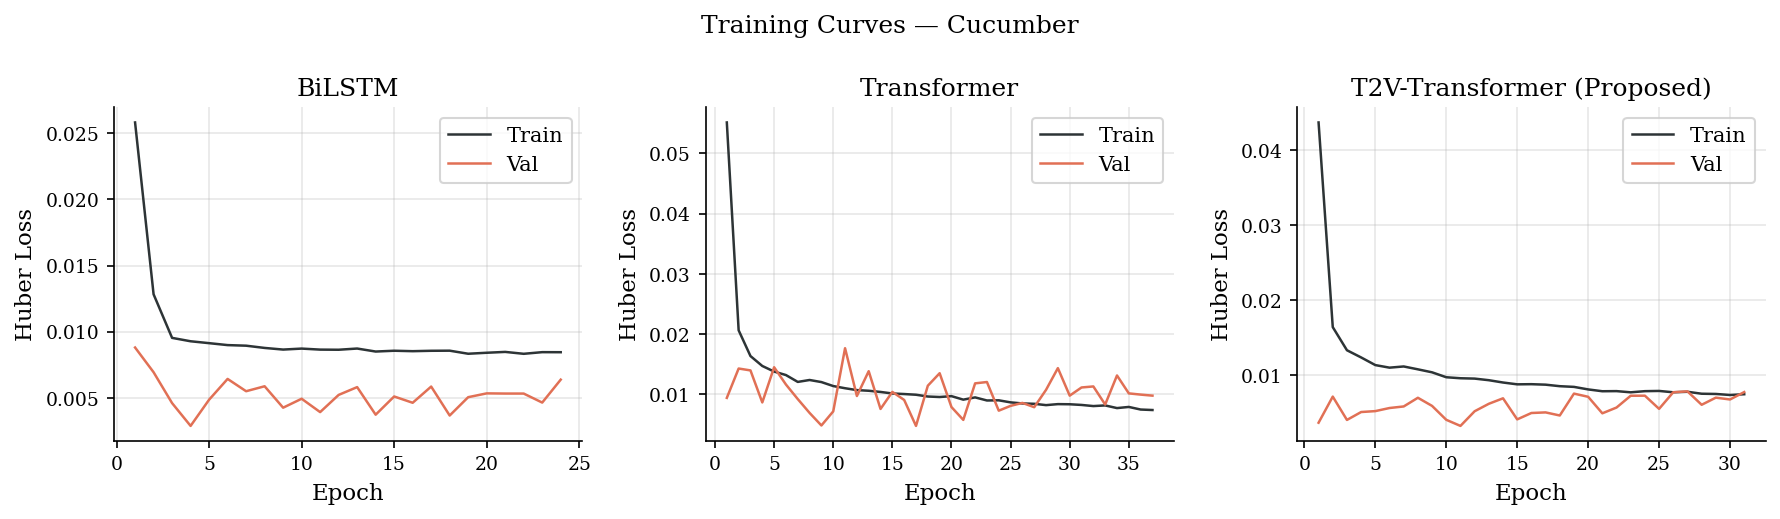

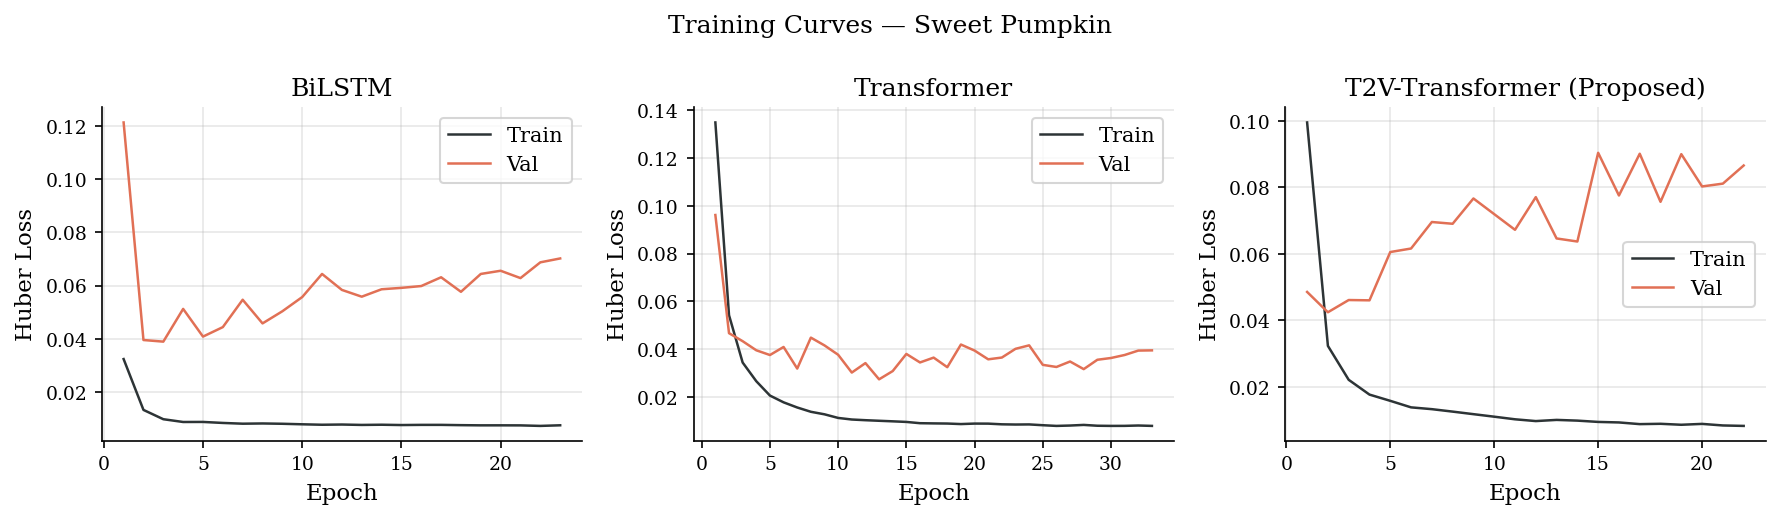

In [12]:
# ── Cell 11: Training curves ────────────────────────────────────────────────
for commodity in COMMODITY_PATHS:
    fig = plot_training_curves(
        all_histories[commodity], commodity,
        save_path=f'figures/training_{commodity}.pdf'
    )
    plt.show()

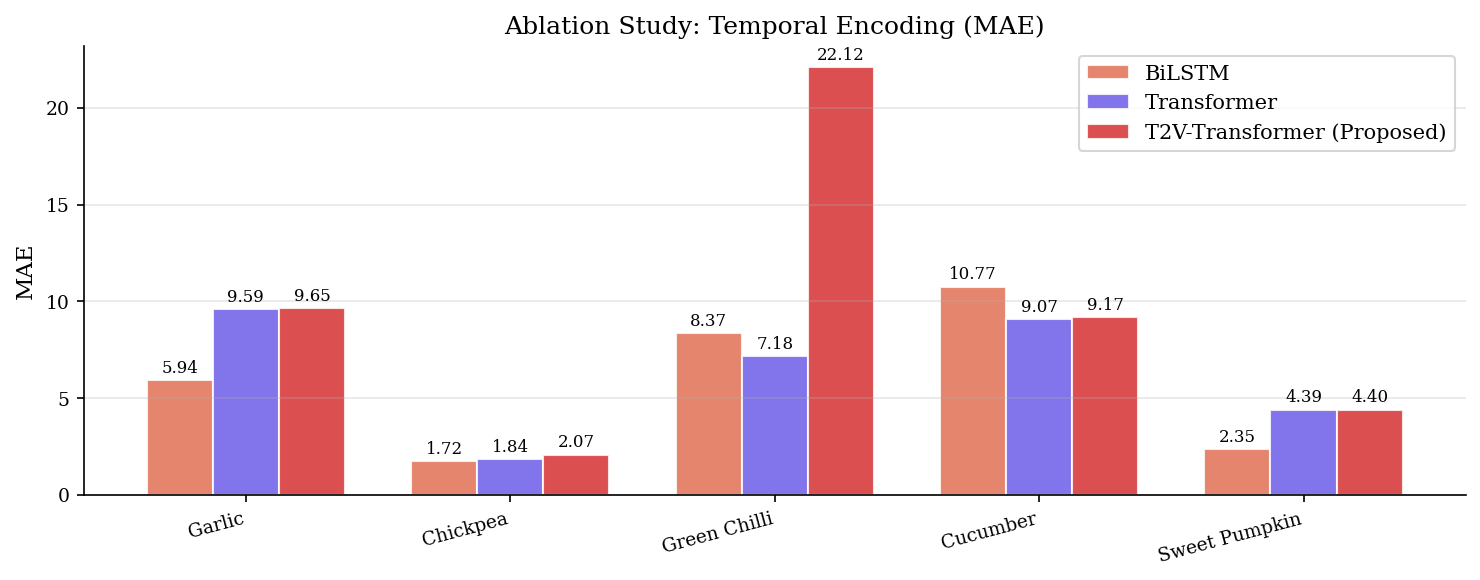

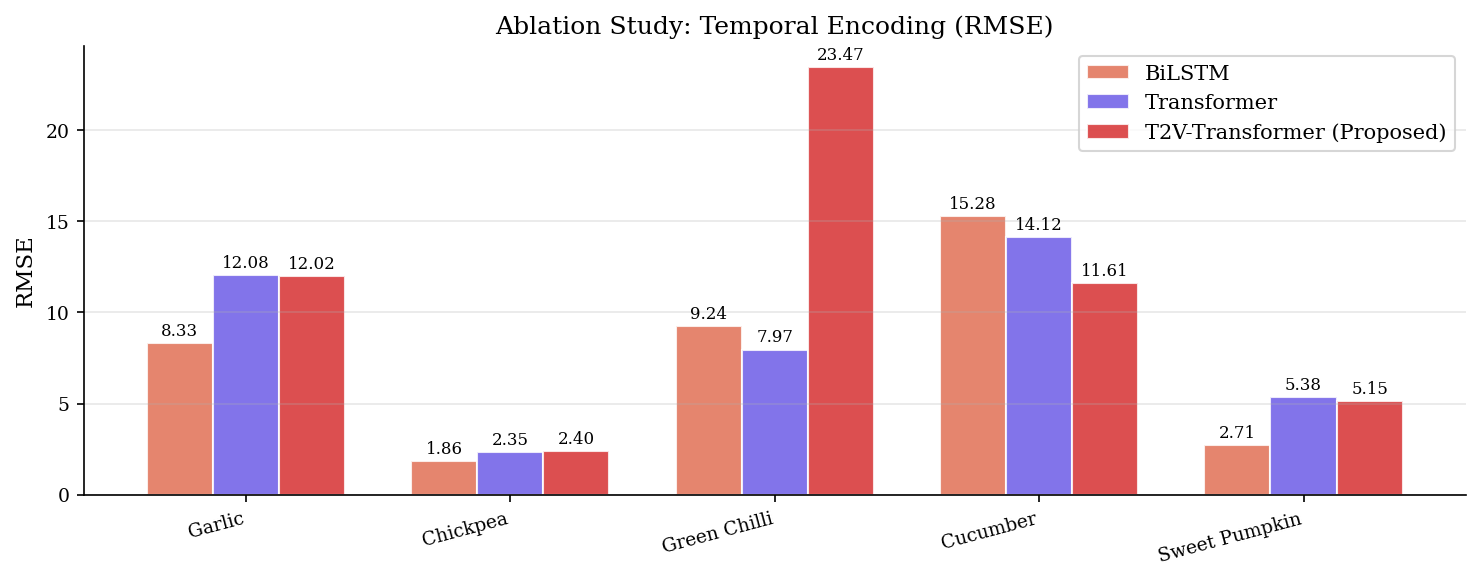

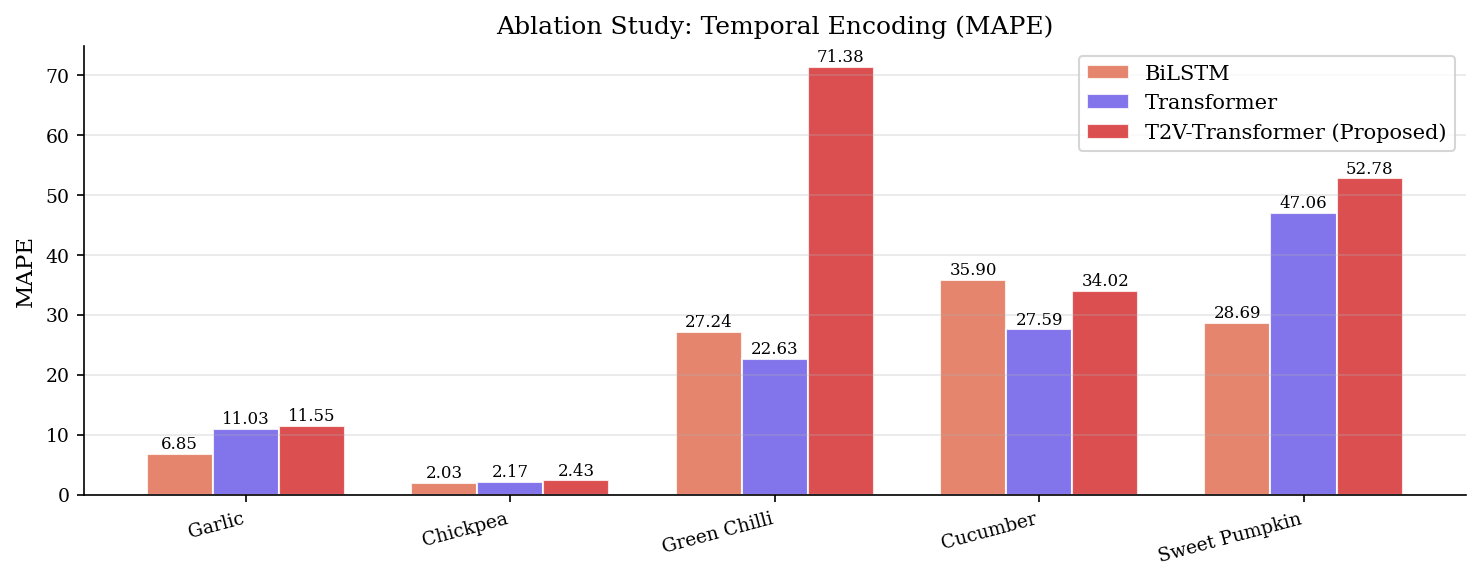

In [13]:
# ── Cell 12: Ablation study ─────────────────────────────────────────────────
# T2V-Transformer vs Vanilla Transformer: isolates the contribution of
# learnable temporal encoding (Time2Vec) vs fixed sinusoidal PE.
for metric in ['MAE', 'RMSE', 'MAPE']:
    fig = plot_ablation(
        all_results, metric=metric,
        save_path=f'figures/ablation_{metric}.pdf'
    )
    plt.show()

In [14]:
# ── Cell 13: Diebold-Mariano test (HLN small-sample correction) ────────────
# Tests whether each DL model is statistically significantly different from
# the Naïve Persistence baseline. Follows Harvey, Leybourne & Newbold (1997).
# h=14 (forecast horizon), squared-error loss differential.
# Results feed Table 4 (dm_results) in Section 4.4 of the manuscript.

from scipy import stats

def dm_test_hln(actual, pred_ref, pred_cmp, h=14, power=2):
    """
    Diebold-Mariano test with Harvey-Leybourne-Newbold (1997) small-sample
    correction.

    Parameters
    ----------
    actual   : 1D array, ground truth
    pred_ref : 1D array, reference model predictions (Naïve here)
    pred_cmp : 1D array, comparison model predictions
    h        : forecast horizon
    power    : loss power (2 = squared error, 1 = absolute error)

    Returns
    -------
    dm_stat  : HLN-corrected DM statistic
    p_value  : two-sided p-value (t-distribution, df=n-1)
    direction: 'cmp_better' if comparison model has lower loss, else 'ref_better'
    """
    e_ref = actual - pred_ref
    e_cmp = actual - pred_cmp
    d     = np.abs(e_ref)**power - np.abs(e_cmp)**power   # positive → cmp is better
    n     = len(d)

    d_mean  = np.mean(d)
    gamma_0 = np.var(d, ddof=0)

    # Newey-West autocovariance for h-1 lags
    gammas = []
    for k in range(1, h):
        if k < n:
            gamma_k = np.mean((d[k:] - d_mean) * (d[:-k] - d_mean))
            gammas.append(gamma_k)

    var_d    = gamma_0 + 2.0 * sum(gammas)
    var_d    = max(var_d, 1e-12)

    # HLN correction factor (Harvey et al., 1997, eq. 3)
    hln_fac  = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat  = (d_mean / np.sqrt(var_d / n)) * hln_fac
    p_value  = float(2 * (1 - stats.t.cdf(np.abs(dm_stat), df=n - 1)))
    direction = 'cmp_better' if d_mean > 0 else 'ref_better'

    return float(dm_stat), p_value, direction


# ── Run DM test: each DL model vs Naïve on each commodity ─────────────────

DL_MODELS  = ['bilstm', 'transformer', 't2v_transformer']
MODEL_LABELS = {
    'bilstm':         'BiLSTM',
    'transformer':    'Transformer',
    't2v_transformer':'T2V-Transformer',
}
COMMODITIES_DISPLAY = {
    'garlic':        'Garlic',
    'chickpea':      'Chickpea',
    'green_chilli':  'Green Chilli',
    'cucumber':      'Cucumber',
    'sweet_pumpkin': 'Sweet Pumpkin',
}

dm_results = {}   # {commodity: {model: (dm_stat, p_val, sig_flag)}}

print('Diebold-Mariano Test Results (vs. Naïve Persistence baseline)')
print('Positive DM stat → comparison model has lower loss (better)')
print('='*75)
header = f'  {"Commodity":<18} {"Model":<20} {"DM stat":>8} {"p-value":>9} {"Sig.":>6} {"Result"}'
print(header)
print('  ' + '-'*70)

for commodity in COMMODITY_PATHS:
    # Load from .npy files (works even if kernel was restarted after Cell 8)
    try:
        truth    = all_truths[commodity]
        naive_p  = all_forecasts[commodity]['naive']
    except (NameError, KeyError):
        truth   = np.load(f'results/{commodity}_truth.npy')
        naive_p = np.load(f'results/{commodity}_naive_preds.npy')

    dm_results[commodity] = {}

    for model_key in DL_MODELS:
        try:
            cmp_p = all_forecasts[commodity][model_key]
        except (NameError, KeyError):
            cmp_p = np.load(f'results/{commodity}_{model_key}_preds.npy')

        # Align lengths (in case of floating window edges)
        n   = min(len(truth), len(naive_p), len(cmp_p))
        dm, pv, direction = dm_test_hln(truth[:n], naive_p[:n], cmp_p[:n], h=PRED_LEN)

        sig_str = '***' if pv < 0.01 else ('**' if pv < 0.05 else ('*' if pv < 0.10 else 'n.s.'))
        result  = 'CMP better' if direction == 'cmp_better' else 'Naïve better'
        dm_results[commodity][model_key] = (dm, pv, sig_str, direction)

        print(f'  {COMMODITIES_DISPLAY[commodity]:<18} {MODEL_LABELS[model_key]:<20} '
              f'{dm:>+8.3f} {pv:>9.4f} {sig_str:>6}  {result}')

    print()

print('Significance: *** p<0.01  ** p<0.05  * p<0.10  n.s. not significant')
print()
print('→ Copy these values into Table 4 in Section 4.4 of the manuscript.')

Diebold-Mariano Test Results (vs. Naïve Persistence baseline)
Positive DM stat → comparison model has lower loss (better)
  Commodity          Model                 DM stat   p-value   Sig. Result
  ----------------------------------------------------------------------
  Garlic             BiLSTM                 +1.095    0.2739   n.s.  CMP better
  Garlic             Transformer            -5.041    0.0000    ***  Naïve better
  Garlic             T2V-Transformer        -3.264    0.0011    ***  Naïve better

  Chickpea           BiLSTM                -10.442    0.0000    ***  Naïve better
  Chickpea           Transformer            -5.513    0.0000    ***  Naïve better
  Chickpea           T2V-Transformer        -9.342    0.0000    ***  Naïve better

  Green Chilli       BiLSTM                 -9.224    0.0000    ***  Naïve better
  Green Chilli       Transformer            -8.174    0.0000    ***  Naïve better
  Green Chilli       T2V-Transformer       -48.706    0.0000    ***  Naïve

In [ ]:
# ── Cell 13b: Diebold-Mariano test — T2V-Transformer vs Vanilla Transformer ──
# This produces Table 7 of the manuscript.
# Reference model = Vanilla Transformer; comparison model = T2V-Transformer.
# Positive DM stat → T2V-Transformer has lower (better) loss.
# Uses squared-error loss, h=14, HLN small-sample correction.
# NOTE: dm_test_hln() is defined in the cell above — run that cell first.

from scipy import stats

print("Diebold-Mariano Test: T2V-Transformer vs Vanilla Transformer (Table 7)")
print("Positive DM stat → T2V-Transformer has lower loss (better)")
print("="*75)
header = f'  {"Commodity":<18} {"DM stat":>10} {"p-value":>10} {"Direction":<22} {"Sig."}'
print(header)
print("  " + "-"*68)

dm_table7 = {}   # {commodity: (dm_stat, p_val, direction, sig)}

COMMODITIES_DISPLAY_T7 = {
    'garlic':        'Garlic',
    'chickpea':      'Chickpea',
    'green_chilli':  'Green Chilli',
    'cucumber':      'Cucumber',
    'sweet_pumpkin': 'Sweet Pumpkin',
}

for commodity in COMMODITY_PATHS:
    # Load predictions — try in-memory first, then .npy fallback
    try:
        truth   = all_truths[commodity]
        trans_p = all_forecasts[commodity]['transformer']
        t2v_p   = all_forecasts[commodity]['t2v_transformer']
    except (NameError, KeyError):
        truth   = np.load(f'results/{commodity}_truth.npy')
        trans_p = np.load(f'results/{commodity}_transformer_preds.npy')
        t2v_p   = np.load(f'results/{commodity}_t2v_transformer_preds.npy')

    n = min(len(truth), len(trans_p), len(t2v_p))
    # ref=Transformer, cmp=T2V; positive d_mean → T2V better
    dm, pv, direction = dm_test_hln(truth[:n], trans_p[:n], t2v_p[:n], h=PRED_LEN)

    sig_str   = '***' if pv < 0.01 else ('**' if pv < 0.05 else ('*' if pv < 0.10 else 'n.s.'))
    dir_label = 'T2V better' if direction == 'cmp_better' else 'Transformer better'
    dm_table7[commodity] = (dm, pv, dir_label, sig_str)

    print(f'  {COMMODITIES_DISPLAY_T7[commodity]:<18} {dm:>+10.3f} {pv:>10.4f}  {dir_label:<22} {sig_str}')

print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10  n.s. not significant")
print("HLN small-sample correction applied; squared-error loss; h =", PRED_LEN)


In [15]:
# ── Cell 14: Parameter count comparison ────────────────────────────────────
# Confirms T2V-Transformer is not winning by model size.

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_for_count = {
    'BiLSTM': BiLSTM(
        pred_len=PRED_LEN, hidden_dim=64, n_layers=2),
    'Vanilla Transformer': VanillaTransformer(
        pred_len=PRED_LEN, seq_len=SEQ_LEN,
        d_model=64, n_heads=4, n_layers=2, d_ff=256),
    'T2V-Transformer': T2V_Transformer(
        pred_len=PRED_LEN, d_model=64,
        n_heads=4, n_layers=2, d_ff=256, t2v_dim=32),
}

print('\nModel Parameter Counts:')
print('-'*40)
for name, m in models_for_count.items():
    n = count_params(m)
    print(f'  {name:<24} {n:>10,} params')
print('-'*40)
print('T2V-Transformer overhead vs Vanilla: only the Time2Vec embedding layer.')


Model Parameter Counts:
----------------------------------------
  BiLSTM                      135,438 params
  Vanilla Transformer         101,006 params
  T2V-Transformer             103,182 params
----------------------------------------
T2V-Transformer overhead vs Vanilla: only the Time2Vec embedding layer.


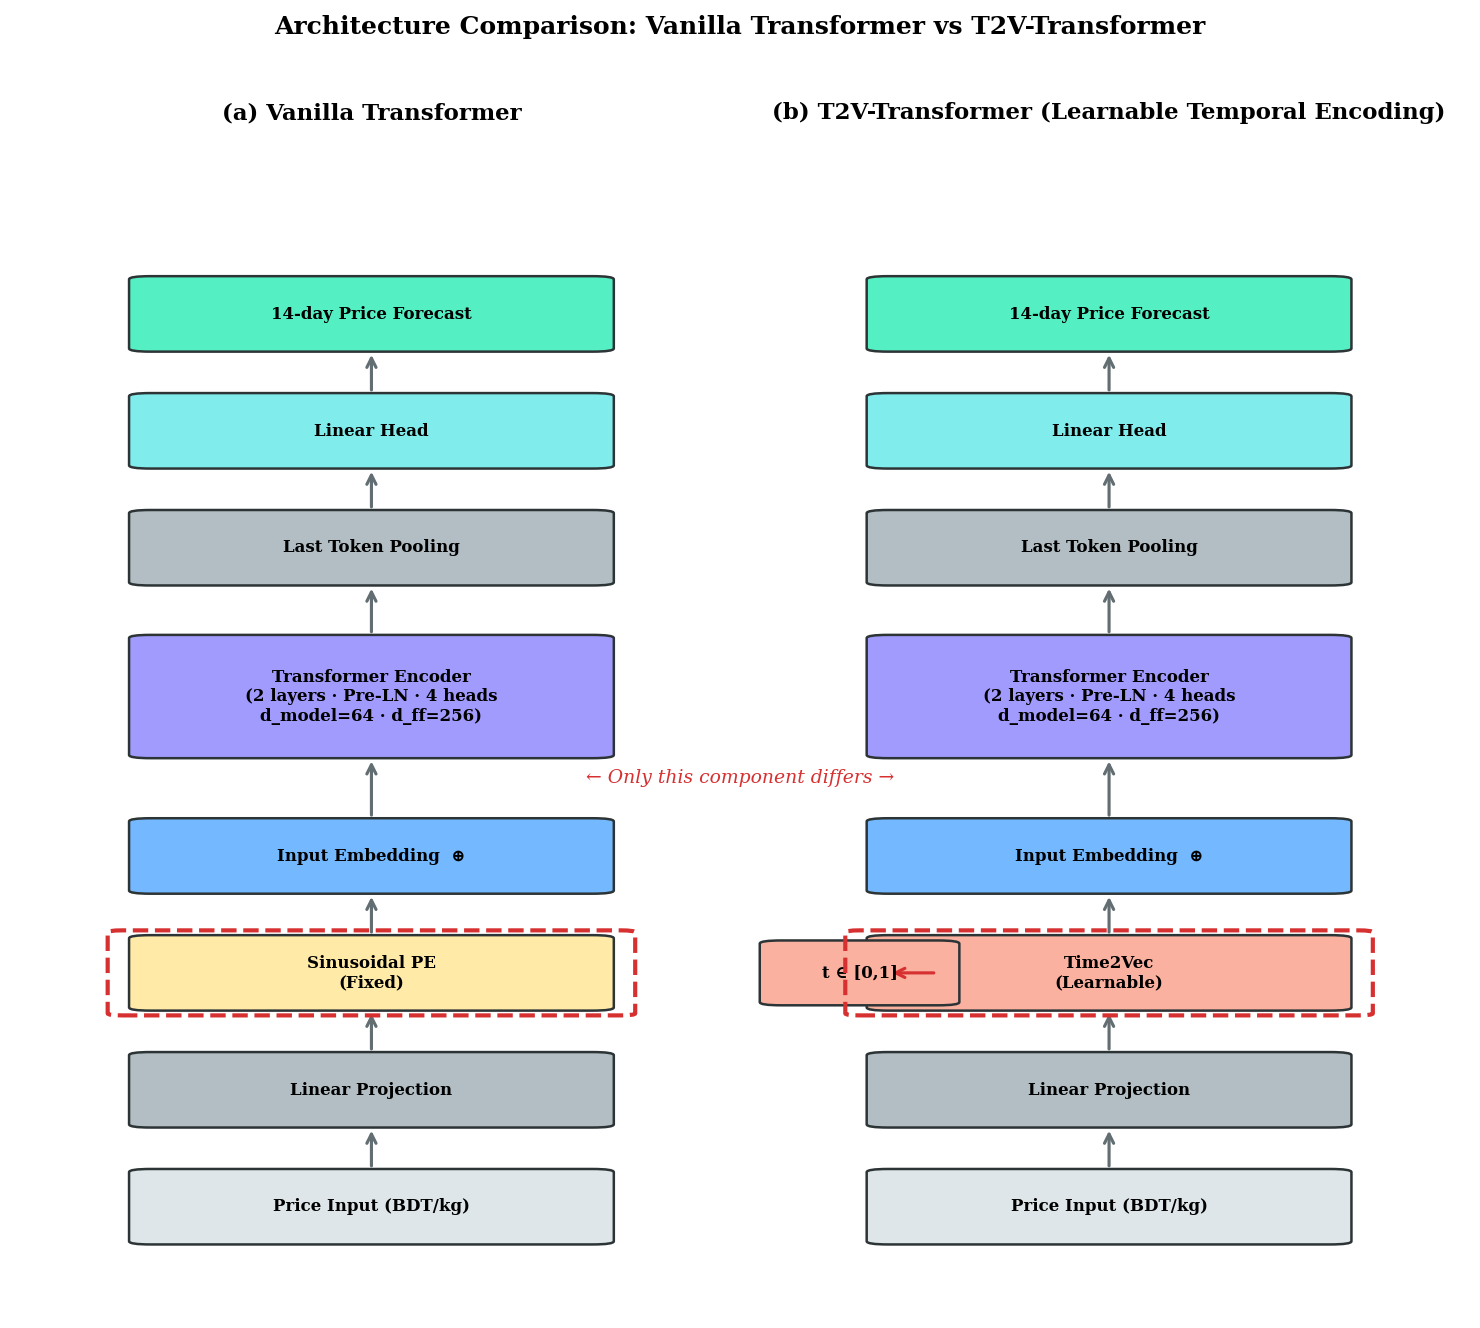

Architecture figure saved.


In [16]:
# ── Cell 15: Architecture comparison figure ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def draw_box(ax, x, y, w, h, label, color, fontsize=9):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.03',
                          facecolor=color, edgecolor='#2d3436',
                          linewidth=1.2, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', zorder=4)

def draw_arrow(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->',
                               color='#636e72', lw=1.5))

def draw_model(ax, title, pe_label, pe_color, has_time_input=False):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 11)
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)

    cx = 0.5
    components = [
        (1.0,  'Price Input (BDT/kg)',              '#dfe6e9', 0.65),
        (2.1,  'Linear Projection',                 '#b2bec3', 0.65),
        (3.2,  pe_label,                             pe_color,  0.65),
        (4.3,  'Input Embedding  ⊕',                '#74b9ff', 0.65),
        (5.8,  'Transformer Encoder\n'
               '(2 layers · Pre-LN · 4 heads\n'
               'd_model=64 · d_ff=256)',            '#a29bfe', 1.1),
        (7.2,  'Last Token Pooling',                '#b2bec3', 0.65),
        (8.3,  'Linear Head',                       '#81ecec', 0.65),
        (9.4,  '14-day Price Forecast',             '#55efc4', 0.65),
    ]

    prev_bottom = None
    for (yc, label, color, h) in components:
        draw_box(ax, cx, yc, 0.62, h, label, color, fontsize=8)
        top    = yc + h/2
        bottom = yc - h/2
        if prev_bottom is not None:
            draw_arrow(ax, cx, prev_bottom + 0.02, bottom - 0.02)
        prev_bottom = top

    if has_time_input:
        draw_box(ax, 0.15, 3.2, 0.22, 0.55,
                 't ∈ [0,1]', '#fab1a0', fontsize=8)
        ax.annotate('', xy=(cx - 0.31, 3.2),
                    xytext=(0.15 + 0.11, 3.2),
                    arrowprops=dict(arrowstyle='->',
                                   color='#d63031', lw=1.5))

    # Dashed highlight around the PE row
    highlight = FancyBboxPatch(
        (cx - 0.35, 3.2 - 0.38), 0.70, 0.76,
        boxstyle='round,pad=0.02',
        facecolor='none', edgecolor='#d63031',
        linewidth=2.0, linestyle='--', zorder=5
    )
    ax.add_patch(highlight)

fig, axes = plt.subplots(1, 2, figsize=(10, 9))

draw_model(axes[0],
           title='(a) Vanilla Transformer',
           pe_label='Sinusoidal PE\n(Fixed)',
           pe_color='#ffeaa7',
           has_time_input=False)

draw_model(axes[1],
           title='(b) T2V-Transformer (Learnable Temporal Encoding)',
           pe_label='Time2Vec\n(Learnable)',
           pe_color='#fab1a0',
           has_time_input=True)

fig.text(0.5, 0.415, '← Only this component differs →',
         ha='center', va='center', fontsize=9,
         color='#d63031', fontstyle='italic')

fig.suptitle('Architecture Comparison: Vanilla Transformer vs T2V-Transformer',
             fontsize=12, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('figures/architecture_comparison.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figures/architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Architecture figure saved.')

In [17]:
# ── Cell 16: Save all figures as zip ──────────────────────────────────────
import shutil
shutil.make_archive('figures', 'zip', 'figures')
shutil.make_archive('results',  'zip', 'results')
print('figures.zip and results.zip saved — download from Files panel on the left.')

figures.zip and results.zip saved — download from Files panel on the left.
